In [1]:
import os
import time
import glob
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             roc_auc_score, log_loss, brier_score_loss, confusion_matrix, 
                             classification_report, roc_curve, precision_recall_curve, balanced_accuracy_score)
from sklearn.calibration import calibration_curve
from statsmodels.discrete.discrete_model import Logit
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

warnings.filterwarnings('ignore')

INDEX = "24adaXXX"
RANDOM_STATE = 42

os.makedirs("figures", exist_ok=True)



## Part A
### Data Loading


In [2]:
csv_filename = f"{INDEX}_Data.csv"
if os.path.exists(csv_filename):
    print(f"Loading cached dataset from {csv_filename}...")
    df = pd.read_csv(csv_filename)
else:
    print("Cached dataset not found. Loading original files...")
    # Attempt Kaggle fallback path
    dataset_dir = "Spotify-Hit-Predictor-Dataset" 
    if not os.path.exists(dataset_dir):
        import kagglehub
        import shutil
        path = kagglehub.dataset_download("theoverman/the-spotify-hit-predictor-dataset")
        shutil.copytree(path, dataset_dir)
        
    csv_files = glob.glob(os.path.join(dataset_dir, "dataset-of-*.csv"))
    if not csv_files:
        csv_files = glob.glob("dataset-of-*.csv")
        
    dfs = []
    for f in csv_files:
        temp_df = pd.read_csv(f)
        decade = os.path.basename(f).replace('dataset-of-', '').replace('s.csv', '')
        temp_df['decade'] = decade
        dfs.append(temp_df)
        
    df = pd.concat(dfs, ignore_index=True)
    df.to_csv(csv_filename, index=False)
    print(f"Data exported to {csv_filename}")
    
print(f"Dataset shape: {df.shape}")


Loading cached dataset from 24adaXXX_Data.csv...
Dataset shape: (41106, 20)


### Dataset Variables
| Variable Name | Type | Role |
|---|---|---|
| track | Nominal | Dropped |
| artist | Nominal | Dropped |
| uri | ID | Dropped |
| danceability | Numeric | Covariate |
| energy | Numeric | Covariate |
| loudness | Numeric | Covariate |
| speechiness | Numeric | Covariate |
| acousticness | Numeric | Covariate |
| instrumentalness | Numeric | Covariate |
| liveness | Numeric | Covariate |
| valence | Numeric | Covariate |
| tempo | Numeric | Covariate |
| duration_ms | Numeric | Covariate |
| chorus_hit | Numeric | Covariate |
| sections | Numeric | Covariate |
| key | Nominal | Covariate |
| mode | Binary | Covariate |
| time_signature | Nominal | Covariate |
| decade | Nominal | Covariate |
| target | Binary | Response |


### Dataset background
- **Source**: *The Spotify Hit Predictor Dataset (1960–2019)*, published on Kaggle by user `theoverman` (https://www.kaggle.com/datasets/theoverman/the-spotify-hit-predictor-dataset). The track features were collected through the Spotify Web API, and the hit labels come from the Billboard Hot 100 archive.
- **Background**: the data was built to study whether a song's audio characteristics can predict commercial success. It has one file per decade (60s, 70s, 80s, 90s, 00s, 10s), and we combine them with a `decade` covariate (`0` = 2000s, `10` = 2010s).
- **Response (`target`)**: 1 = *hit*, meaning the track appeared at least once in the Billboard Hot 100 that decade. 0 = *flop*: the track and its artist never appeared in that decade's Hot 100, it belongs to a non-mainstream / avant-garde genre with no charting songs, and it is available in the US market (author's criteria, see `README.txt`).
- **Covariates (16)**: 12 numerical Spotify audio features (danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, duration_ms, chorus_hit, sections) and 4 categorical ones (key [12 levels], mode [binary], time_signature [5 levels], decade [6 levels]).
- **Size**: 41,106 rows. After removing 546 duplicate tracks, 40,560 rows remain (20,019 hits / 20,541 flops: 49.4% / 50.6%).

In [3]:
# Duplicates checking
duplicated_uris = df[df.duplicated(subset=['uri'], keep=False)]
conflicting_uris = duplicated_uris.groupby('uri')['target'].nunique()
conflicting_count = (conflicting_uris > 1).sum()

df_clean = df.drop_duplicates(subset=['uri']).copy()

print(f"Rows before de-duplication: {len(df)}")
print(f"Rows removed: {len(df) - len(df_clean)}")
print(f"Rows after de-duplication: {len(df_clean)}")
print(f"Duplicate uri values with conflicting target labels (first occurrence kept): {conflicting_count}")
df_clean = df_clean.drop(columns=['track', 'artist', 'uri', 'chord'], errors='ignore')

print(f"Columns used for modelling ({df_clean.shape[1] - 1} covariates + target): {list(df_clean.columns)}")
print(df_clean['target'].value_counts().rename('count'))
print(f"\nClass balance after de-duplication:\n{df_clean['target'].value_counts(normalize=True)}")


Rows before de-duplication: 41106
Rows removed: 546
Rows after de-duplication: 40560
Duplicate uri values with conflicting target labels (first occurrence kept): 26
Columns used for modelling (16 covariates + target): ['danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'time_signature', 'chorus_hit', 'sections', 'target', 'decade']
target
0    20541
1    20019
Name: count, dtype: int64

Class balance after de-duplication:
target
0    0.506435
1    0.493565
Name: proportion, dtype: float64


The same Spotify `uri` can appear in two decade files when a track was re-released or charted across decades. We keep the first occurrence of each `uri`, which removes 546 rows. Of these duplicates, 26 had *conflicting* labels (a hit in one decade, a flop in another). Keeping one copy prevents the same song from landing in both the training and test sets, which would leak information. `track`, `artist` and `uri` are identifiers with no predictive meaning and are dropped. The classes stay almost perfectly balanced (49.4% hits), so no resampling is needed.

## Part B
### B.1 Cleaning


In [4]:
print(f"Missing values:\n{df_clean.isna().sum()}\nTotal: {df_clean.isna().sum().sum()}")
tempo_0_count = (df_clean['tempo'] == 0).sum()
ts_0_count = (df_clean['time_signature'] == 0).sum()
print(f"Count of tempo == 0: {tempo_0_count}")
print(f"Count of time_signature == 0: {ts_0_count}")

cat_features = ['key', 'mode', 'time_signature', 'decade']
num_features = [c for c in df_clean.columns if c not in cat_features and c != 'target']

df_encoded = pd.get_dummies(df_clean, columns=['key', 'time_signature', 'decade'], drop_first=True)
df_encoded = df_encoded.astype({col: 'int' for col in df_encoded.select_dtypes('bool').columns})


Missing values:
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms         0
time_signature      0
chorus_hit          0
sections            0
target              0
decade              0
dtype: int64
Total: 0
Count of tempo == 0: 1
Count of time_signature == 0: 3


**B.1 summary.** There are no missing values in any column. Only 1 track has `tempo = 0` and 3 tracks have `time_signature = 0` (Spotify's code for "could not be estimated", typical of spoken-word or ambient tracks). These are valid, not data-entry errors, so they are kept, and the sensitivity check after C.5 shows that removing them changes nothing. The nominal variables `key`, `time_signature` and `decade` are one-hot encoded with the first level as reference. `mode` is already 0/1. Numerical features are standardised only for logistic regression (Part C) so that coefficients are comparable per 1 SD.

### B.2 Distributions


,count,mean,std,min,25%,50%,75%,max,skewness,% zero
danceability,40560.0,0.538791,0.177907,0.000000,0.419000,0.551000,0.66800,0.988,-0.249024,0.002465
energy,40560.0,0.578632,0.253198,0.000251,0.394000,0.600000,0.78700,1.000,-0.315168,0.000000
loudness,40560.0,-10.247409,5.326406,-49.253000,-12.847000,-9.282000,-6.39000,3.744,-1.412031,0.000000
speechiness,40560.0,0.072988,0.086183,0.000000,0.033700,0.043500,0.06990,0.960,4.590703,0.002465
acousticness,40560.0,0.365995,0.339686,0.000000,0.039500,0.261000,0.67925,0.996,0.484295,0.019724
instrumentalness,40560.0,0.156192,0.304890,0.000000,0.000000,0.000126,0.06610,1.000,1.726731,28.330868
liveness,40560.0,0.201770,0.173249,0.013000,0.094100,0.132000,0.26125,0.999,2.122903,0.000000
valence,40560.0,0.541591,0.267556,0.000000,0.329000,0.557000,0.76700,0.996,-0.176879,0.034517
tempo,40560.0,119.325267,29.123819,0.000000,97.340250,117.523000,136.53225,241.423,0.484152,0.002465
duration_ms,40560.0,234738.991593,119544.807675,15168.000000,172553.250000,217560.000000,266587.00000,4170227.000,6.813544,0.000000


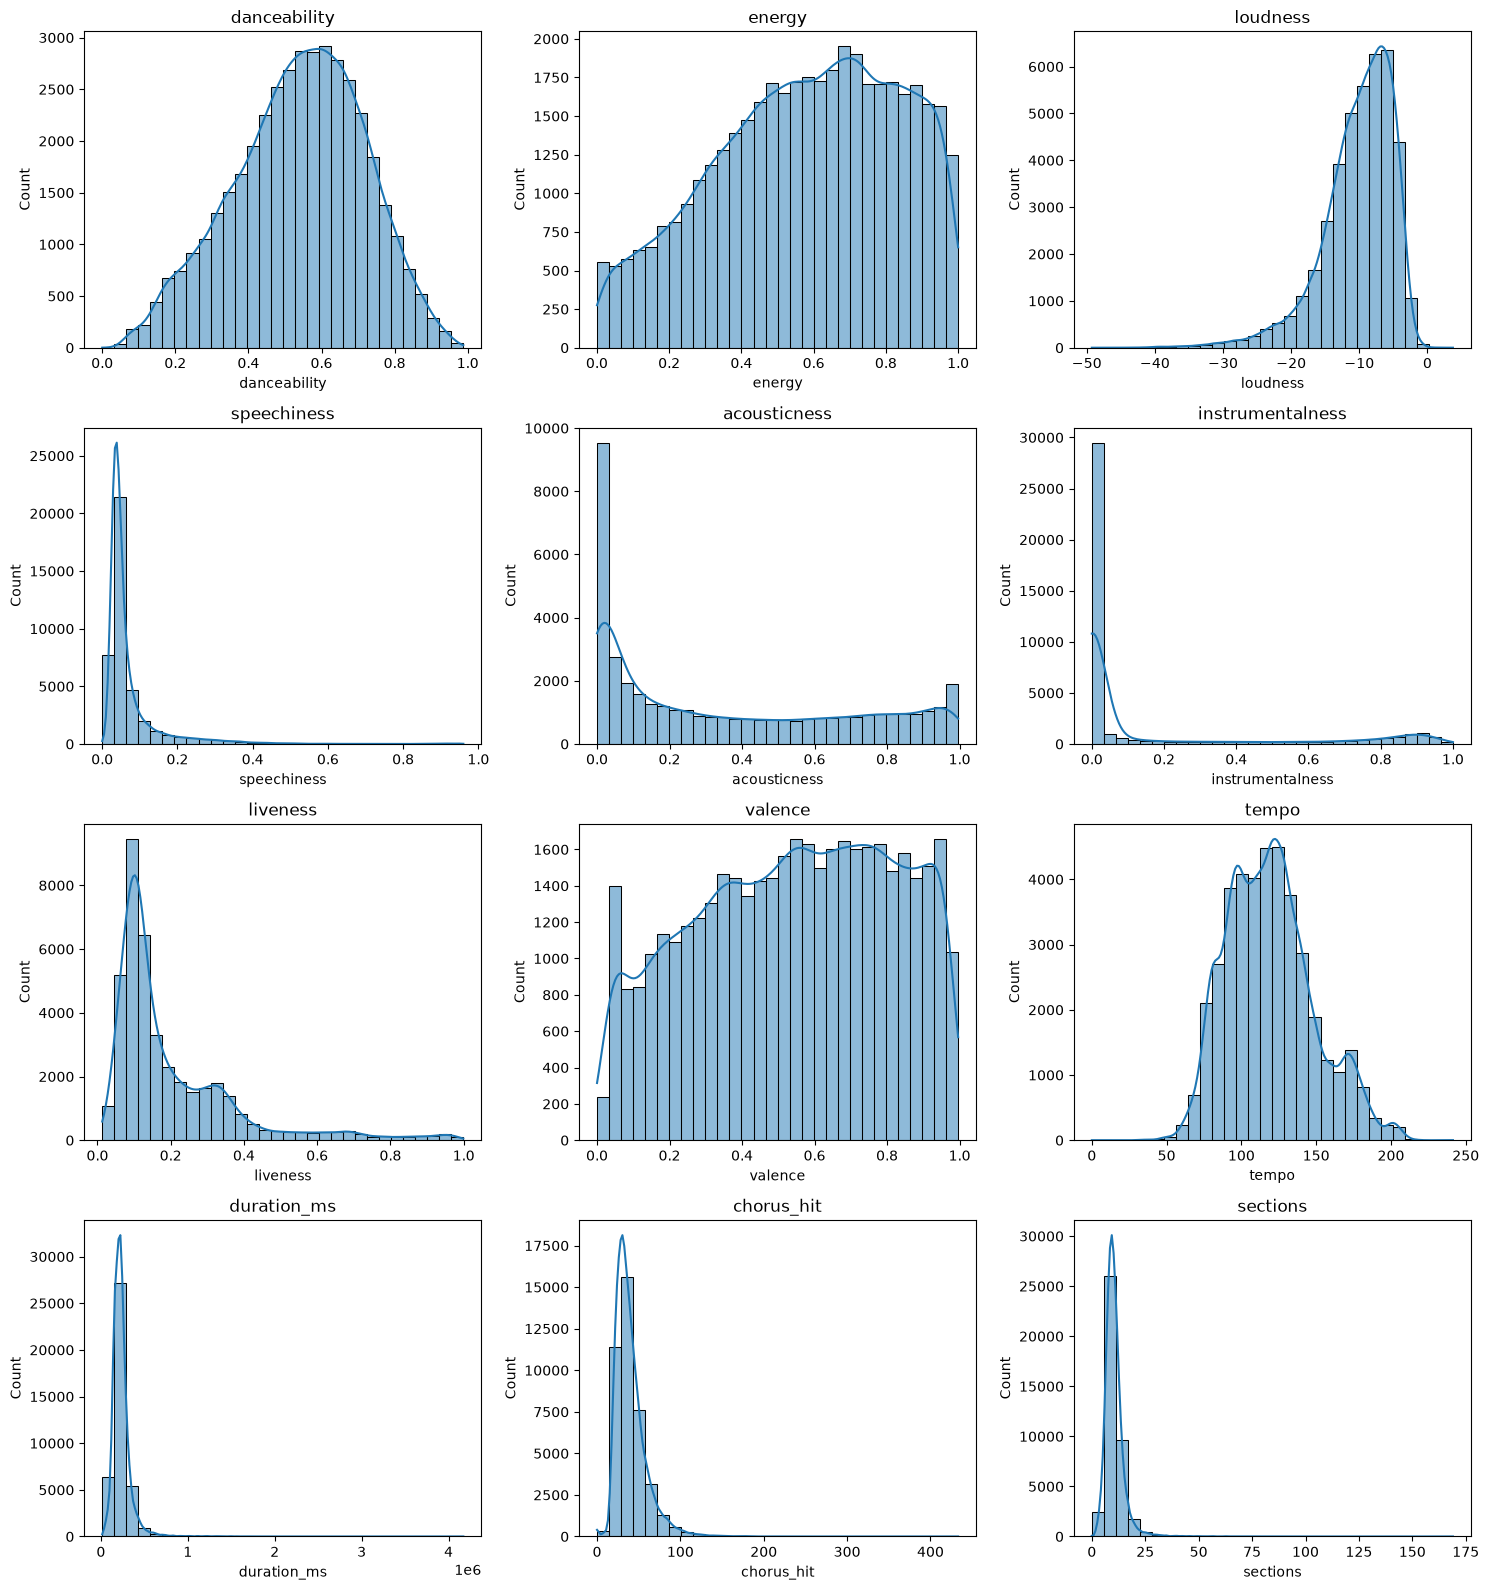

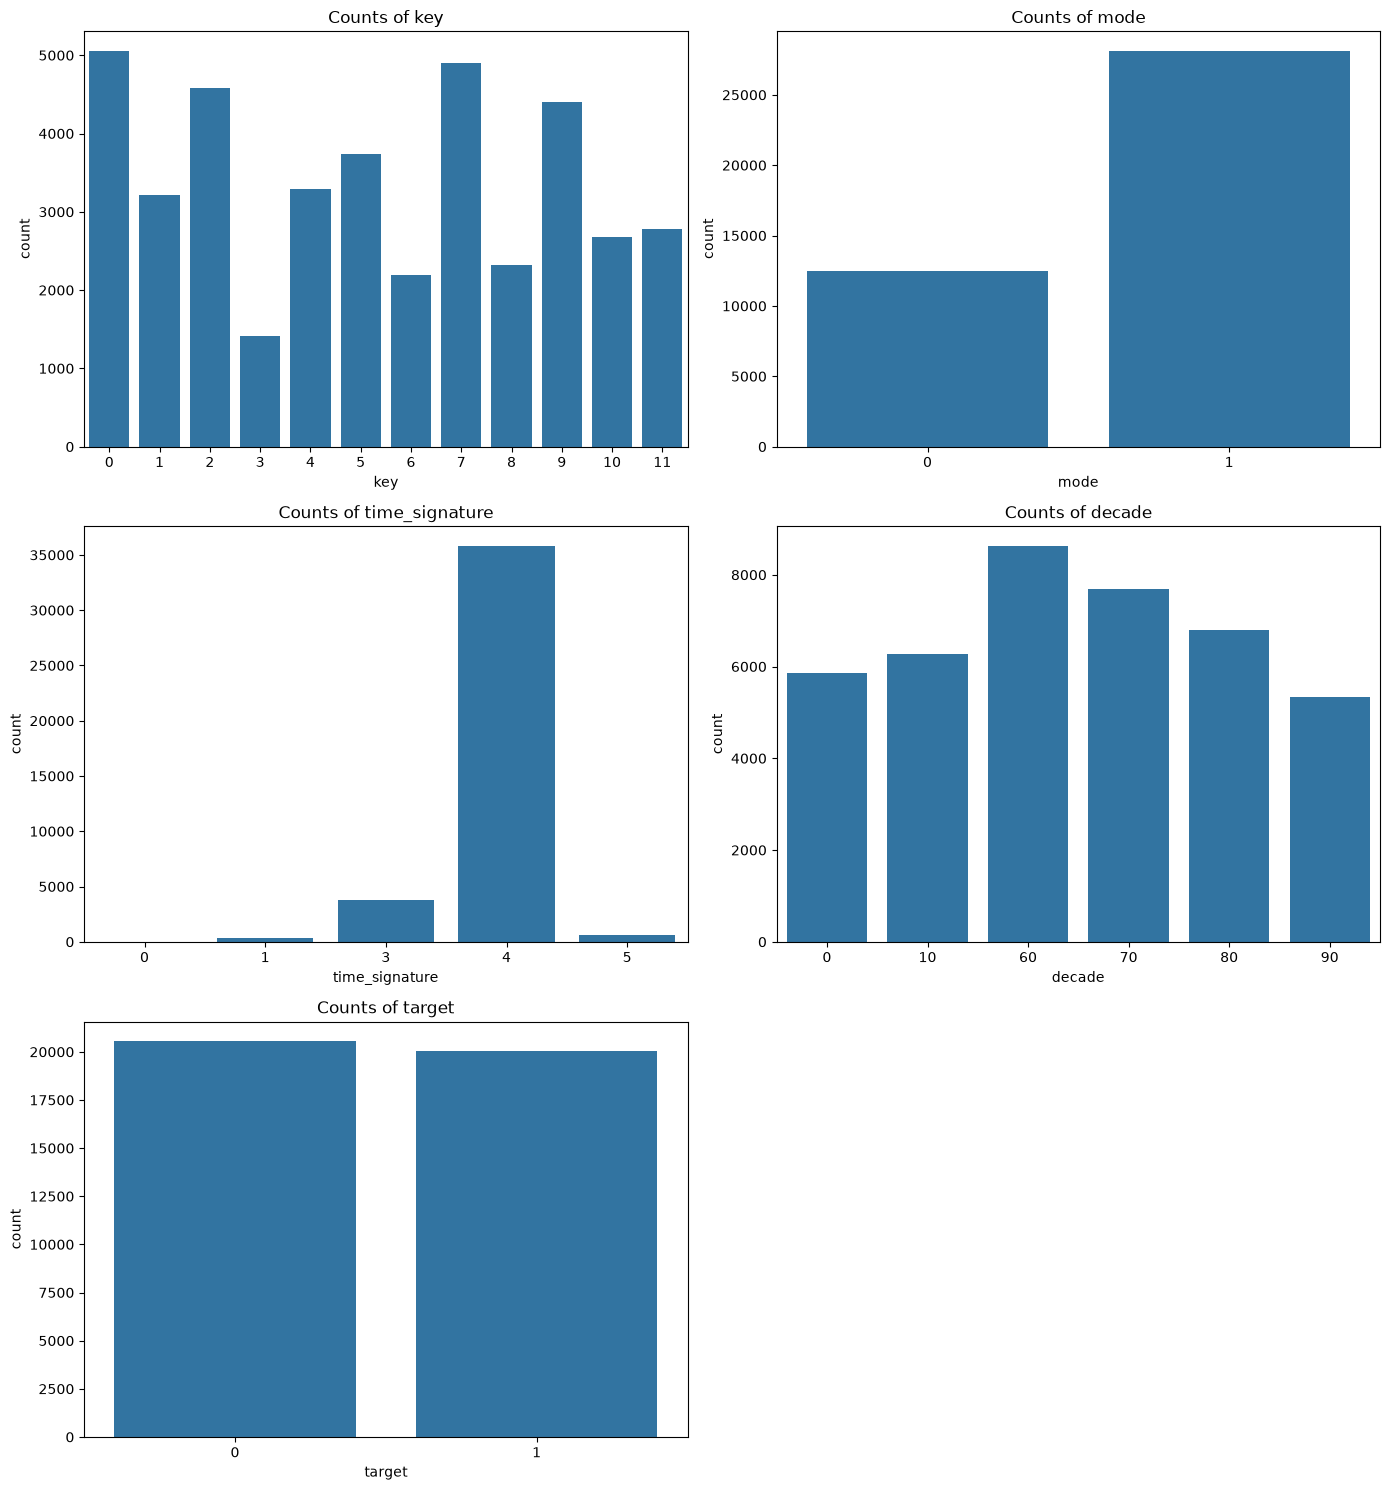

In [5]:
desc = df_clean[num_features].describe().T
desc['skewness'] = df_clean[num_features].skew()
desc['% zero'] = (df_clean[num_features] == 0).mean() * 100
display(desc)

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig("figures/fig_B2_histograms.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()
for i, col in enumerate(['key', 'mode', 'time_signature', 'decade', 'target']):
    sns.countplot(data=df_clean, x=col, ax=axes[i])
    axes[i].set_title(f"Counts of {col}")
axes[-1].axis('off')
plt.tight_layout()
plt.savefig("figures/fig_B2_barcharts.png", dpi=200, bbox_inches="tight")
plt.show()


**B.2 summary.**
- *Roughly symmetric*: danceability (mean 0.54), energy (0.58), valence (0.54), tempo (mean 119 BPM).
- *Strongly right-skewed*: speechiness (skew 4.6), duration_ms (6.8; median 3.6 min, max 69.5 min), sections (6.1), chorus_hit (2.2), liveness (2.1).
- *Left-skewed*: loudness (−1.4; most tracks between −13 and −6 dB).
- *Zero-inflated*: instrumentalness is exactly 0 for 28% of tracks and below 0.001 for 59%. The rest spread out towards 1.
- *Categorical*: 69% of tracks are in a major key (`mode = 1`). `time_signature` is dominated by 4/4 (35,784 tracks), with 3/4 (3,816), 5/4 (588), 1/4 (369) and 0 (3). Decades are fairly even (5,330–8,622 tracks each). The response is balanced (49.4% hits).

### B.3 Relationships with the target


,Feature,Test,Statistic,p-value,Effect size,Effect label
5,instrumentalness,Mann-Whitney U,1.069716e+08,0.000000e+00,-0.479723,medium
0,danceability,Mann-Whitney U,2.861604e+08,0.000000e+00,0.391796,medium
2,loudness,Mann-Whitney U,2.641499e+08,0.000000e+00,0.284743,small
7,valence,Mann-Whitney U,2.629918e+08,0.000000e+00,0.279111,small
4,acousticness,Mann-Whitney U,1.659569e+08,6.090372e-248,-0.192837,small
1,energy,Mann-Whitney U,2.406087e+08,1.020621e-193,0.170246,small
14,time_signature,Chi-Square,9.704646e+02,8.977169e-209,0.154682,small
3,speechiness,Mann-Whitney U,1.747516e+08,5.770972e-151,-0.150062,small
13,mode,Chi-Square,2.575773e+02,5.789259e-58,0.079690,negligible
6,liveness,Mann-Whitney U,1.926189e+08,3.230838e-28,-0.063161,negligible


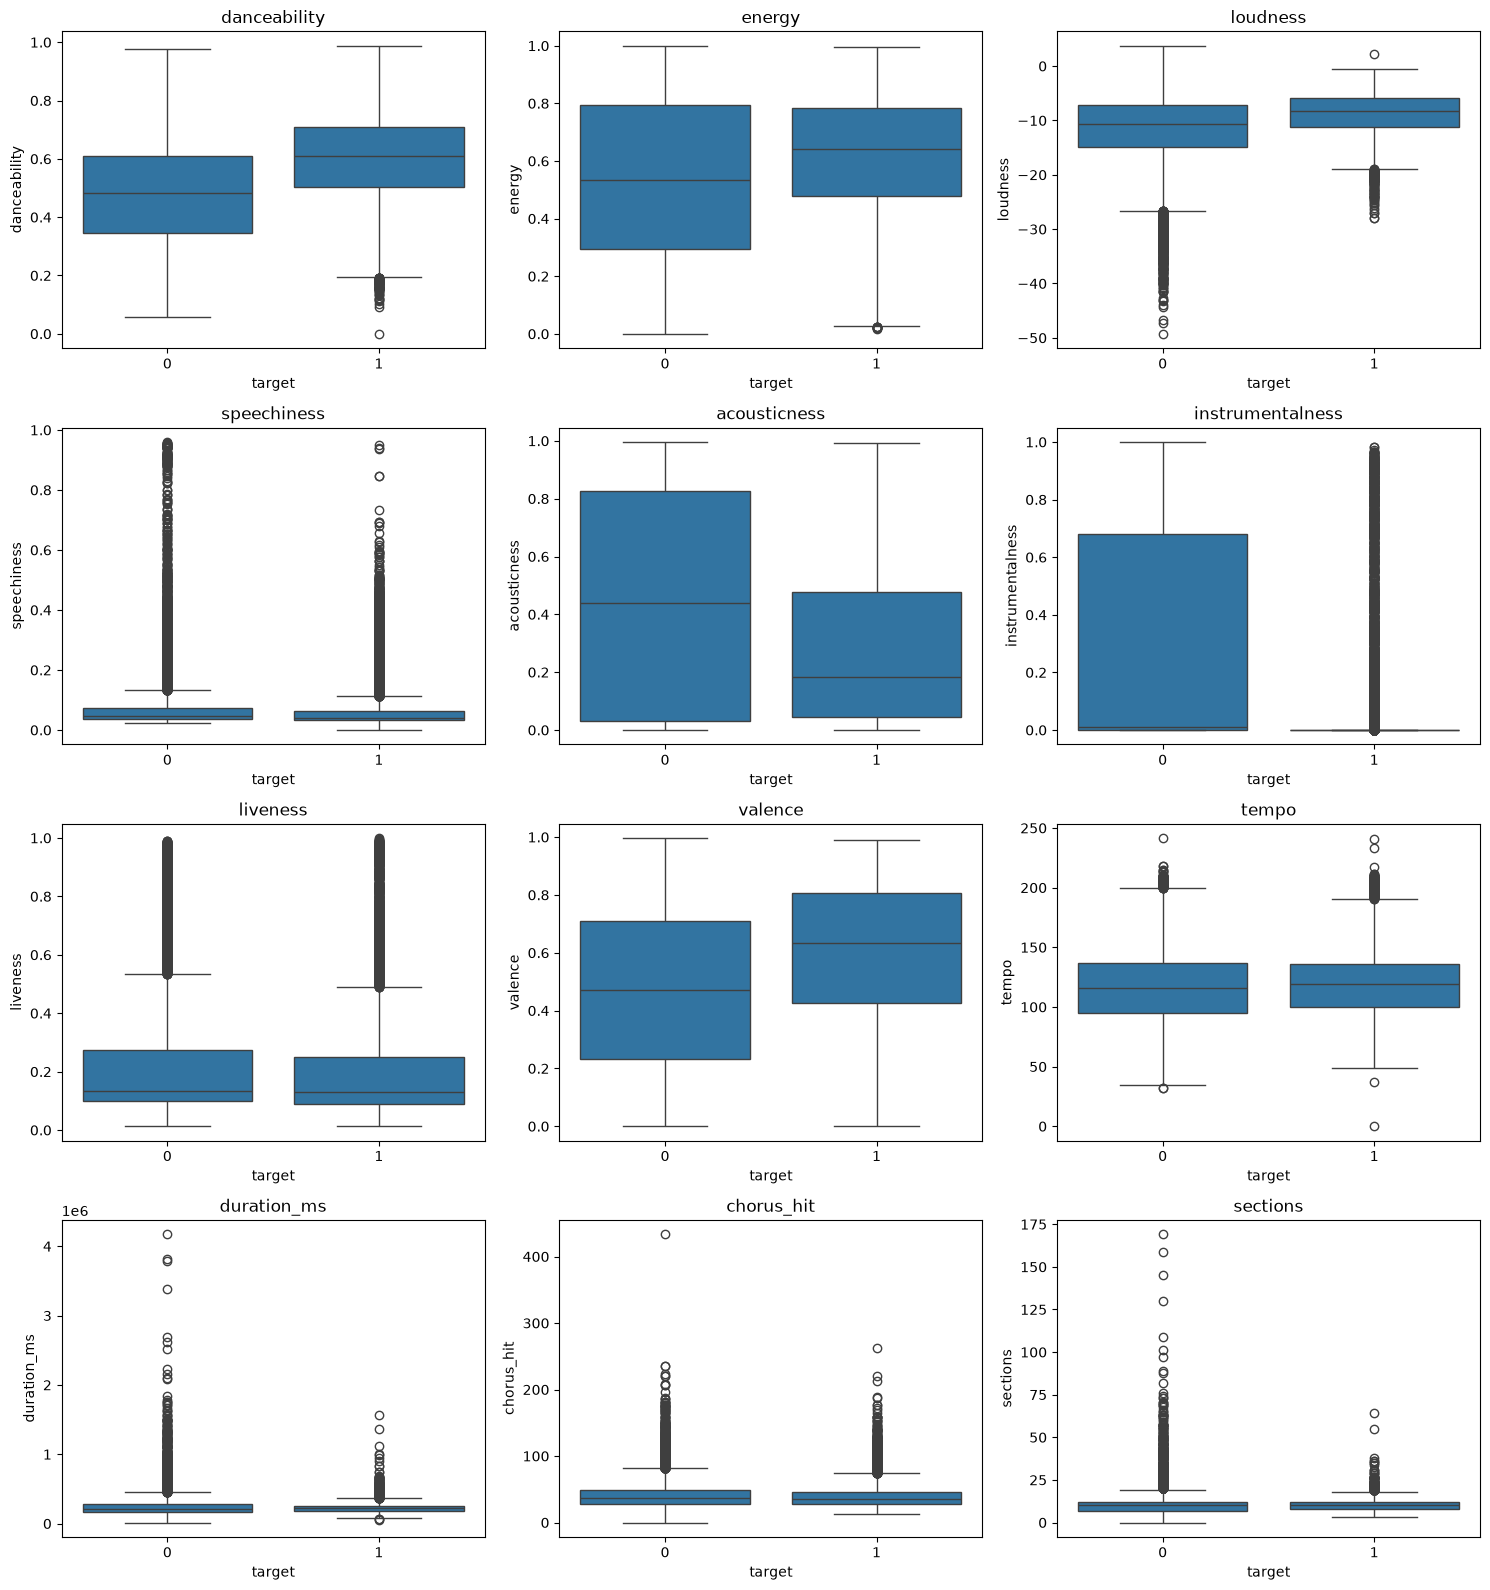

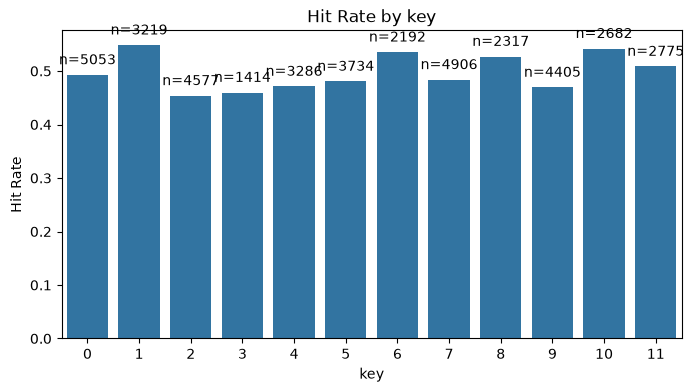

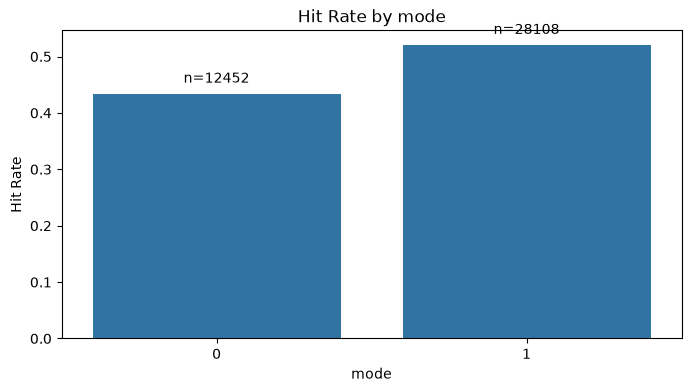

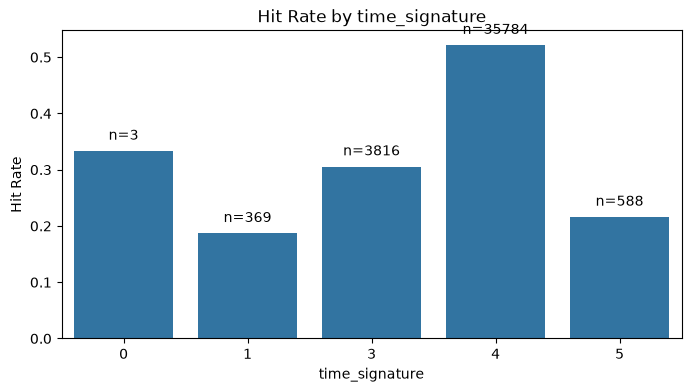

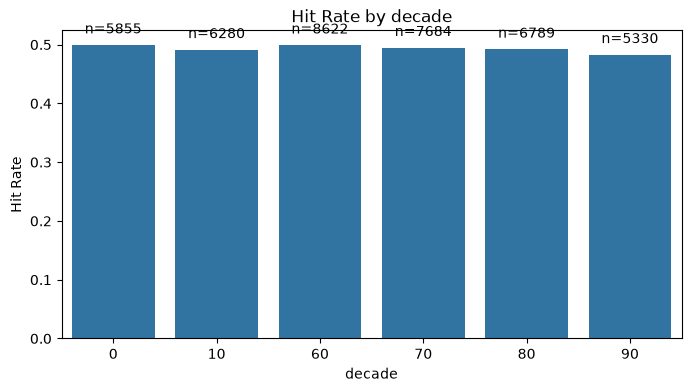

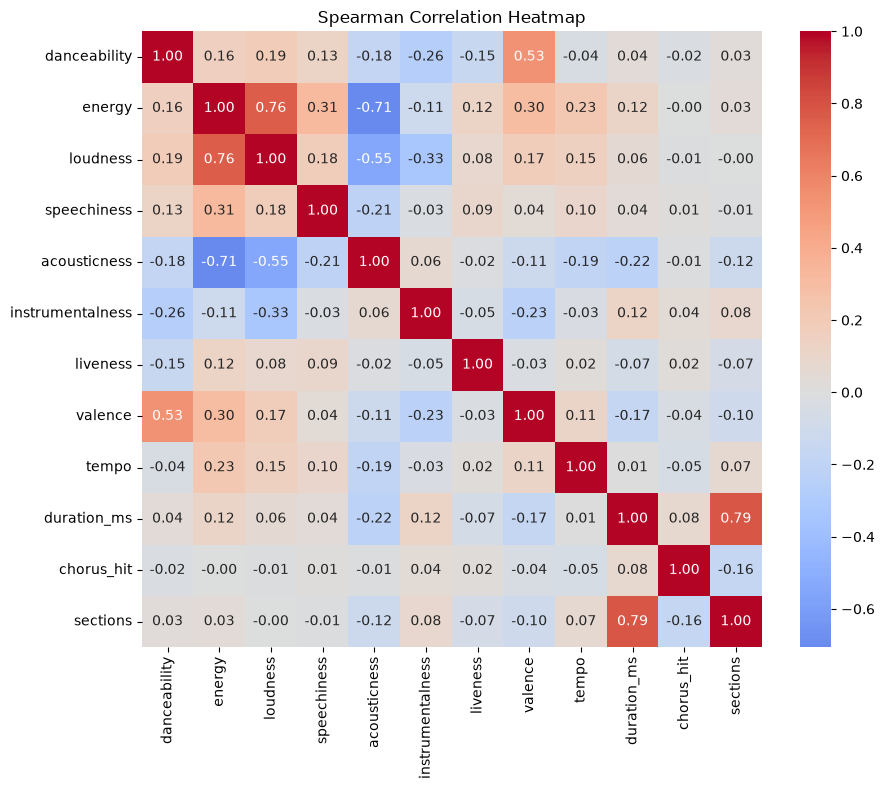

In [6]:
results_list = []
for f in num_features:
    g1 = df_clean[df_clean['target'] == 1][f]
    g0 = df_clean[df_clean['target'] == 0][f]
    u_stat, p_val = stats.mannwhitneyu(g1, g0, alternative='two-sided')
    n1, n0 = len(g1), len(g0)
    r = (2 * u_stat) / (n0 * n1) - 1
    abs_r = abs(r)
    label = "negligible" if abs_r < 0.1 else ("small" if abs_r < 0.3 else ("medium" if abs_r < 0.5 else "large"))
    results_list.append({"Feature": f, "Test": "Mann-Whitney U", "Statistic": u_stat, "p-value": p_val, "Effect size": r, "Effect label": label})

n = len(df_clean)
for f in cat_features:
    cont = pd.crosstab(df_clean[f], df_clean['target'])
    chi2, p_val, dof, exp = stats.chi2_contingency(cont)
    min_dim = min(cont.shape) - 1
    v = np.sqrt(chi2 / (n * min_dim))
    label = "negligible" if v < 0.1 else ("small" if v < 0.3 else ("medium" if v < 0.5 else "large"))
    results_list.append({"Feature": f, "Test": "Chi-Square", "Statistic": chi2, "p-value": p_val, "Effect size": v, "Effect label": label})

rel_df = pd.DataFrame(results_list).sort_values(by="Effect size", key=abs, ascending=False)
display(rel_df)

fig, axes = plt.subplots(4, 3, figsize=(15, 16))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.boxplot(data=df_clean, x='target', y=col, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig("figures/fig_B3_boxplots.png", dpi=200, bbox_inches="tight")
plt.show()

for f in cat_features:
    grp = df_clean.groupby(f)['target'].agg(['mean', 'count']).reset_index()
    plt.figure(figsize=(8, 4))
    sns.barplot(data=grp, x=f, y='mean')
    for i, row in grp.iterrows():
        plt.text(i, row['mean'] + 0.02, f"n={int(row['count'])}", ha='center')
        if row['count'] < 50:
            print(f"WARNING: Feature {f} level {row[f]} has fewer than 50 rows (n={int(row['count'])}).")
    plt.title(f"Hit Rate by {f}")
    plt.ylabel("Hit Rate")
    plt.savefig(f"figures/fig_B3_hitrate_{f}.png", dpi=200, bbox_inches="tight")
    plt.show()

plt.figure(figsize=(10, 8))
corr = df_clean[num_features].corr(method='spearman')
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman Correlation Heatmap")
plt.savefig("figures/fig_B3_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()


**B.3 summary.** With n ≈ 40,000, almost every test is "significant", so we judge relationships by **effect size** (rank-biserial r for Mann-Whitney, Cramér's V for χ²).
- **Medium effects**: *instrumentalness* (r = −0.48; hits are almost never instrumental) and *danceability* (r = +0.39; hits are more danceable).
- **Small effects**: loudness (+0.28), valence (+0.28), acousticness (−0.19), energy (+0.17), time_signature (V = 0.15; 4/4 tracks have a 52% hit rate vs. 19–31% for other metres) and speechiness (−0.15).
- **Negligible**: mode (V = 0.08; 52% hit rate in major vs. 43% in minor), liveness, key, tempo, chorus_hit, sections and duration_ms. **decade** is the only non-significant variable (V = 0.01, p = 0.48), because the dataset has roughly 50% hits within every decade by design.
- The Spearman heatmap shows strong correlations among sections and duration_ms (0.79), energy and loudness (0.76), and energy and acousticness (−0.71). These matter for logistic-regression standard errors (see VIF in B.4).

### B.4 Outliers and influence


In [7]:
outlier_counts = []
for col in num_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df_clean[(df_clean[col] < Q1 - 1.5 * IQR) | (df_clean[col] > Q3 + 1.5 * IQR)]
    outlier_counts.append({"Feature": col, "Outlier Count": len(outliers), "% of rows": len(outliers) / len(df_clean) * 100})
outlier_df = pd.DataFrame(outlier_counts)
display(outlier_df)

inst_zero = (df_clean['instrumentalness'] < 0.001).mean() * 100
print(f"Instrumentalness is zero-inflated ({inst_zero:.1f}% of values < 0.001). Its IQR 'outliers' reflect this skew, not data errors.")

X_vif = add_constant(df_clean[num_features])
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
vif_data = vif_data[vif_data['Feature'] != 'const'].reset_index(drop=True)
display(vif_data)

high_vif = vif_data[vif_data['VIF'] > 5]
for _, row in high_vif.iterrows():
    f = row['Feature']
    corrs = corr[f].drop(f).abs().sort_values(ascending=False)
    top_corr_feat = corrs.index[0]
    top_corr_val = corrs.iloc[0]
    infl = np.sqrt(row['VIF'])
    print(f"Feature {f} has VIF > 5 (VIF={row['VIF']:.2f}). Pairwise correlation with {top_corr_feat} is {top_corr_val:.2f}. Standard error is inflated by factor {infl:.2f}.")


,Feature,Outlier Count,% of rows
0,danceability,1,0.002465
1,energy,0,0.000000
2,loudness,1329,3.276627
3,speechiness,4959,12.226331
4,acousticness,0,0.000000
5,instrumentalness,8778,21.642012
6,liveness,2662,6.563116
7,valence,0,0.000000
8,tempo,424,1.045365
9,duration_ms,1968,4.852071


Instrumentalness is zero-inflated (58.8% of values < 0.001). Its IQR 'outliers' reflect this skew, not data errors.


,Feature,VIF
0,danceability,1.781335
1,energy,4.277003
2,loudness,2.969014
3,speechiness,1.092864
4,acousticness,2.256313
5,instrumentalness,1.305008
6,liveness,1.088374
7,valence,1.816794
8,tempo,1.110703
9,duration_ms,5.888196


Feature duration_ms has VIF > 5 (VIF=5.89). Pairwise correlation with sections is 0.79. Standard error is inflated by factor 2.43.
Feature sections has VIF > 5 (VIF=5.76). Pairwise correlation with duration_ms is 0.79. Standard error is inflated by factor 2.40.


**B.4: Outliers, influence and unusual patterns.**
- **IQR outliers** are common in the skewed variables: instrumentalness 21.6%, speechiness 12.2%, liveness 6.6%, duration_ms 4.9%, chorus_hit 4.5%. These are real musical extremes (rap tracks with high speechiness, live recordings, 10-minute progressive-rock songs), not errors, and removing more than 20% of the data would bias the sample. **All are retained.** Tree models are unaffected by extreme x-values, and in the logistic model their influence is checked directly with Cook's distance (C.5): the largest Cook's D is 0.021, far below the usual concern level of 0.5–1, so no single track dominates the fit.
- **Unusual patterns** that may affect modelling: (i) instrumentalness is zero-inflated, so a single linear term may not capture it (confirmed by the empirical-logit plot in C.4); (ii) duration_ms has a *non-monotone* relationship with hit rate (10% hits below 2 min, about 58% at 3–5 min, 20% above 6 min), which a linear logit cannot represent; (iii) `time_signature = 0` has only 3 tracks, which gives huge standard errors for the time-signature dummies in the LR.
- **Multicollinearity**: duration_ms (VIF 5.9) and sections (VIF 5.8) are correlated (ρ = 0.79), inflating their LR standard errors by about 2.4×. They are kept here, and the BIC selection in C.3 resolves the problem by dropping duration_ms. All other VIFs are below 4.3.

### B.5 Two expected important predictors


In [8]:
auc_scores = {}
for col in num_features:
    auc = roc_auc_score(df_clean['target'], df_clean[col])
    auc_scores[col] = max(auc, 1 - auc)
auc_df = pd.DataFrame(list(auc_scores.items()), columns=['Feature', 'AUC']).sort_values('AUC', ascending=False).reset_index(drop=True)
top2 = auc_df.head(2)['Feature'].tolist()

for f in top2:
    auc_val = auc_df[auc_df['Feature']==f]['AUC'].values[0]
    med_hit = df_clean[df_clean['target']==1][f].median()
    med_flop = df_clean[df_clean['target']==0][f].median()
    print(f"Feature '{f}' has an individual AUC of {auc_val:.3f}. The median for Hits is {med_hit:.3f}, and for Flops is {med_flop:.3f}.")


Feature 'instrumentalness' has an individual AUC of 0.740. The median for Hits is 0.000, and for Flops is 0.011.
Feature 'danceability' has an individual AUC of 0.696. The median for Hits is 0.609, and for Flops is 0.483.


**B.5: Two variables expected to be most important.**
1. **instrumentalness**: largest univariate AUC (0.740) and the largest effect size (r = −0.48). The median hit has instrumentalness 0.000 vs. 0.011 for flops. Popular-chart songs nearly always have vocals, while the flop sample has many instrumental, ambient and electronic tracks.
2. **danceability**: second-highest AUC (0.696, r = +0.39). The median hit has danceability 0.61 vs. 0.48 for flops, which fits the importance of rhythm and groove in chart music.

Both are also only weakly correlated with each other (Spearman ρ = −0.26), so each should add separate information in a multivariable model.

### B.6 Split


In [9]:
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
X_train = X_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print(f"Train class balance:\n{y_train.value_counts(normalize=True)}\n")
print(f"Test class balance:\n{y_test.value_counts(normalize=True)}")


Train class balance:
target
0    0.506441
1    0.493559
Name: proportion, dtype: float64

Test class balance:
target
0    0.50641
1    0.49359
Name: proportion, dtype: float64


**B.6.** The data is split 80:20 into a training set (32,448 tracks) and a test set (8,112 tracks), stratified on `target` so both keep the 49.4% hit rate. The seed is fixed (`random_state = 42`). All model fitting, feature selection, tuning and threshold choice use the training set only. The test set is used once, for the final evaluation.

## Part C: Logistic Regression
### C.1 Full model


In [10]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

X_train_sm = add_constant(X_train_scaled)
X_test_sm = add_constant(X_test_scaled)

log_reg_sm = Logit(y_train, X_train_sm).fit(disp=0)
print(log_reg_sm.summary())
print(f"\nConvergence Flag: {log_reg_sm.mle_retvals['converged']}")

high_coefs = log_reg_sm.params[abs(log_reg_sm.params) > 10]
high_bse = log_reg_sm.bse[log_reg_sm.bse > 5]
if len(high_coefs) > 0: print(f"WARNING: High coefficients detected:\n{high_coefs}")
if len(high_bse) > 0: print(f"WARNING: High standard errors detected:\n{high_bse}")

results_df = pd.DataFrame({
    'Coefficient': log_reg_sm.params,
    'z': log_reg_sm.tvalues,
    'p-value': log_reg_sm.pvalues,
    'Odds Ratio': np.exp(log_reg_sm.params),
    '95% CI Lower': np.exp(log_reg_sm.conf_int()[0]),
    '95% CI Upper': np.exp(log_reg_sm.conf_int()[1])
}).sort_values(by='z', key=abs, ascending=False)
display(results_df)


                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                32448
Model:                          Logit   Df Residuals:                    32414
Method:                           MLE   Df Model:                           33
Date:                Tue, 06 Oct 2026   Pseudo R-squ.:                  0.2552
Time:                        10:12:14   Log-Likelihood:                -16750.
converged:                       True   LL-Null:                       -22489.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.8685      1.441      0.603      0.547      -1.955       3.692
danceability         0.7205      0.020     36.027      0.000       0.681       0.760
energy              -0.4653 



Convergence Flag: True


,Coefficient,z,p-value,Odds Ratio,95% CI Lower,95% CI Upper
instrumentalness,-1.019871,-43.894715,0.000000e+00,0.360641,0.344587,0.377444
danceability,0.720548,36.026738,3.191324e-284,2.055560,1.976541,2.137738
acousticness,-0.620392,-28.689851,5.106867e-181,0.537734,0.515419,0.561014
loudness,0.708259,24.069706,5.191667e-128,2.030453,1.916664,2.150997
decade_60,1.088015,19.455786,2.603291e-84,2.968376,2.660220,3.312227
speechiness,-0.248404,-16.112409,2.087315e-58,0.780045,0.756827,0.803975
energy,-0.465289,-15.830559,1.915125e-56,0.627954,0.592801,0.665190
decade_70,0.758992,14.365554,8.512345e-47,2.136121,1.925987,2.369182
mode,0.404896,13.290613,2.624188e-40,1.499147,1.412253,1.591388
tempo,0.095490,6.691889,2.203084e-11,1.100198,1.069854,1.131402


**C.1.** The full model uses all 16 covariates (33 parameters + intercept after dummy coding) and converges. Numerical covariates are standardised, so each odds ratio is *per 1 SD*. The model is highly significant overall (LR χ² = 11,478 on 33 df, p < 0.001), with McFadden pseudo-R² = 0.255. Most audio features are significant at 5%; duration_ms (p = 0.91), sections (p = 0.08) and all four time_signature dummies are not. The time_signature dummies (and the intercept) have very large standard errors (≈ 1.44) because their reference level, `time_signature = 0`, contains only 3 tracks.

### C.2 Top three predictors


In [11]:
top3_predictors = results_df.drop('const').head(3).index.tolist()
for f in top3_predictors:
    if f in num_features:
        idx = num_features.index(f)
        sd = scaler.scale_[idx]
        or_val = results_df.loc[f, 'Odds Ratio']
        direction = 'increases' if results_df.loc[f, 'Coefficient'] > 0 else 'decreases'
        meaning = 'higher' if direction == 'increases' else 'lower'
        print(f"For {f}, the Odds Ratio per 1 SD ({sd:.3f} original units) is {or_val:.3f}. This indicates that as {f} increases, the odds of being a Hit {direction}, meaning {meaning} {f} is practically associated with hits.")
    else:
        or_val = results_df.loc[f, 'Odds Ratio']
        direction = 'higher' if results_df.loc[f, 'Coefficient'] > 0 else 'lower'
        print(f"For {f} (categorical), the Odds Ratio is {or_val:.3f}. Being in this category results in {direction} odds of being a Hit compared to the baseline.")


For instrumentalness, the Odds Ratio per 1 SD (0.306 original units) is 0.361. This indicates that as instrumentalness increases, the odds of being a Hit decreases, meaning lower instrumentalness is practically associated with hits.
For danceability, the Odds Ratio per 1 SD (0.178 original units) is 2.056. This indicates that as danceability increases, the odds of being a Hit increases, meaning higher danceability is practically associated with hits.
For acousticness, the Odds Ratio per 1 SD (0.340 original units) is 0.538. This indicates that as acousticness increases, the odds of being a Hit decreases, meaning lower acousticness is practically associated with hits.


**C.2: Three most significant predictors** (ranked by |z|, since all three p-values underflow to 0):

| Predictor | 1 SD | OR per 1 SD (95% CI) | Interpretation |
|---|---|---|---|
| instrumentalness | 0.306 | **0.36** (0.34–0.38) | Holding other features fixed, a 0.31 increase in instrumentalness cuts the odds of being a hit by about **64%**. Vocal tracks are far more likely to chart. |
| danceability | 0.178 | **2.06** (1.98–2.14) | A 0.18 increase in danceability (e.g. 0.50 → 0.68) roughly **doubles** the odds of a hit. |
| acousticness | 0.340 | **0.54** (0.52–0.56) | A 0.34 increase in acousticness lowers the odds of a hit by about **46%**, once loudness, energy and decade are controlled for. Produced, electric sounds are favoured. |

All three directions match the EDA (B.3), so the multivariable model confirms the univariate picture.

### C.3 Reduced model


In [12]:
groups = {f: [f] for f in num_features}
groups['mode'] = ['mode']
groups['key'] = [c for c in X_train_scaled.columns if c.startswith('key_')]
groups['time_signature'] = [c for c in X_train_scaled.columns if c.startswith('time_signature_')]
groups['decade'] = [c for c in X_train_scaled.columns if c.startswith('decade_')]

current_groups = list(groups.keys())
current_bic = log_reg_sm.bic
print(f"Initial BIC: {current_bic:.2f}")

while True:
    best_bic = current_bic
    best_group_to_drop = None
    
    for g in current_groups:
        cols_to_keep = []
        for cg in current_groups:
            if cg != g:
                cols_to_keep.extend(groups[cg])
        
        temp_X = add_constant(X_train_scaled[cols_to_keep])
        temp_model = Logit(y_train, temp_X).fit(disp=0)
        
        if temp_model.bic < best_bic:
            best_bic = temp_model.bic
            best_group_to_drop = g
            
    if best_group_to_drop is not None:
        print(f"Dropping {best_group_to_drop} improved BIC to {best_bic:.2f}")
        current_groups.remove(best_group_to_drop)
        current_bic = best_bic
    else:
        break

retained_vars = []
for g in current_groups:
    retained_vars.extend(groups[g])

removed_groups = [g for g in groups.keys() if g not in current_groups]
print(f"\nVariables removed: {removed_groups}")
print(f"Variables retained: {current_groups}")

selected_features = retained_vars

X_train_reduced_sm = add_constant(X_train_scaled[selected_features])
X_test_reduced_sm = add_constant(X_test_scaled[selected_features])
reduced_log_reg_sm = Logit(y_train, X_train_reduced_sm).fit(disp=0)

full_preds = log_reg_sm.predict(X_test_sm)
red_preds = reduced_log_reg_sm.predict(X_test_reduced_sm)
full_auc = roc_auc_score(y_test, full_preds)
red_auc = roc_auc_score(y_test, red_preds)

lr_stat = 2 * (log_reg_sm.llf - reduced_log_reg_sm.llf)
df_diff = log_reg_sm.df_model - reduced_log_reg_sm.df_model
lr_p = stats.chi2.sf(lr_stat, df_diff)

comp_df = pd.DataFrame({
    'Metric': ['Parameters', 'Log-Likelihood', 'AIC', 'BIC', 'McFadden R2', 'Test AUC', 'LR p-value (Full vs Red)'],
    'Full Model': [log_reg_sm.df_model+1, log_reg_sm.llf, log_reg_sm.aic, log_reg_sm.bic, log_reg_sm.prsquared, full_auc, np.nan],
    'Reduced Model': [reduced_log_reg_sm.df_model+1, reduced_log_reg_sm.llf, reduced_log_reg_sm.aic, reduced_log_reg_sm.bic, reduced_log_reg_sm.prsquared, red_auc, lr_p]
})
display(comp_df)


Initial BIC: 33853.89


Dropping duration_ms improved BIC to 33843.52


Dropping time_signature improved BIC to 33841.89



Variables removed: ['duration_ms', 'time_signature']
Variables retained: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'chorus_hit', 'sections', 'mode', 'key', 'decade']


,Metric,Full Model,Reduced Model
0,Parameters,34.000000,2.900000e+01
1,Log-Likelihood,-16750.360511,-1.677033e+04
2,AIC,33568.721022,3.359866e+04
3,BIC,33853.892421,3.384189e+04
4,McFadden R2,0.255160,2.542725e-01
5,Test AUC,0.815287,8.147349e-01
6,LR p-value (Full vs Red),NaN,1.537595e-07


**C.3: Reduced model.** We ran backward elimination with **BIC**, removing *whole variables* (all dummies of a factor together) one at a time while BIC kept falling. BIC was chosen over AIC or p-values because, with n = 32,448, its ln(n) penalty favours a parsimonious model that predicts as well as the full one. Two variables were removed: **duration_ms** (BIC 33,854 → 33,844) and **time_signature** (→ 33,842). This also fixes the duration_ms/sections collinearity and the unstable time-signature dummies. The reduced model keeps 14 variables (29 parameters). Its test AUC is essentially the same as the full model's (0.8147 vs. 0.8153). The likelihood-ratio test still rejects the reduction (p = 1.5×10⁻⁷), but at this sample size the LR test detects effects too small to matter for prediction, and BIC's stronger penalty is designed for this situation.

### C.4 Adequacy and performance


Reduced Model LR Test vs Null: stat=11436.44, p=0.00e+00
Reduced Model AIC: 33598.66 | BIC: 33841.89 | McFadden R2: 0.2543
Hosmer-Lemeshow Test: stat=80.27, p=4.32e-14


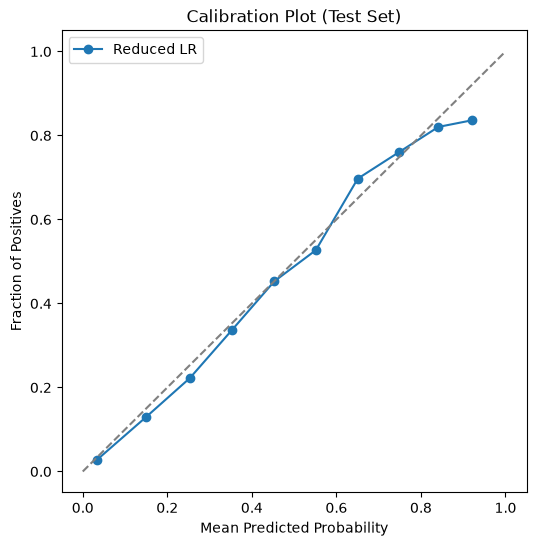

Brier Score (Test): 0.1728


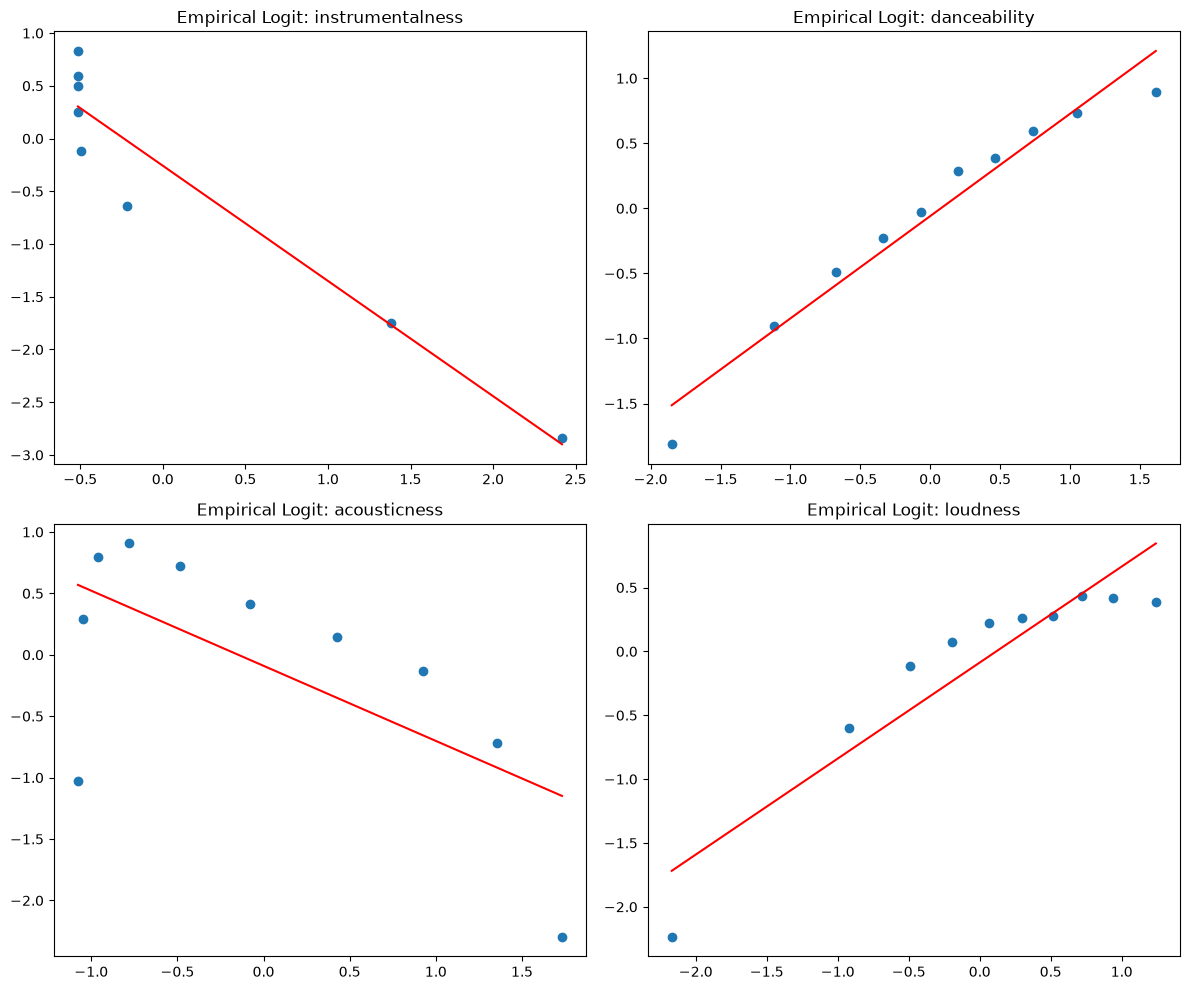

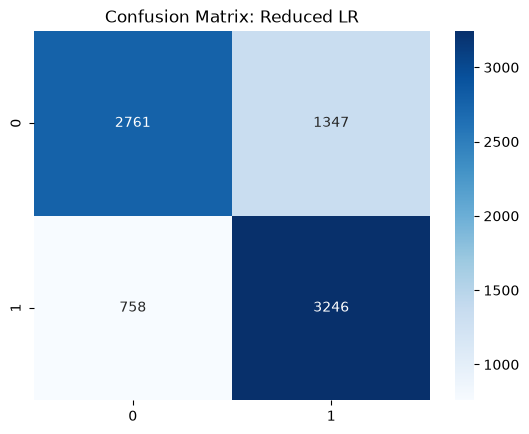

Test Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.67      0.72      4108
           1       0.71      0.81      0.76      4004

    accuracy                           0.74      8112
   macro avg       0.75      0.74      0.74      8112
weighted avg       0.75      0.74      0.74      8112

Train Accuracy: 0.7436 | Train AUC: 0.8131
Test Accuracy: 0.7405 | Test AUC: 0.8147 | Log Loss: 0.5137


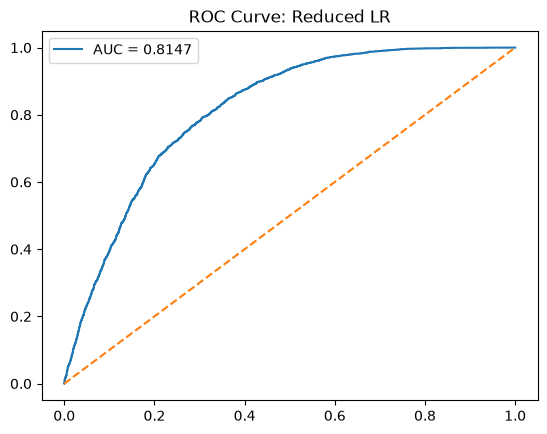

In [13]:
print(f"Reduced Model LR Test vs Null: stat={reduced_log_reg_sm.llr:.2f}, p={reduced_log_reg_sm.llr_pvalue:.2e}")
print(f"Reduced Model AIC: {reduced_log_reg_sm.aic:.2f} | BIC: {reduced_log_reg_sm.bic:.2f} | McFadden R2: {reduced_log_reg_sm.prsquared:.4f}")

# Hosmer-Lemeshow
train_preds = reduced_log_reg_sm.predict(X_train_reduced_sm)
df_hl = pd.DataFrame({'y': y_train, 'p': train_preds})
df_hl['g'] = pd.qcut(df_hl['p'], 10, duplicates='drop')
grp = df_hl.groupby('g', observed=False)
hl_stat = ((grp['y'].sum() - grp['y'].count() * grp['p'].mean())**2 / (grp['y'].count() * grp['p'].mean() * (1 - grp['p'].mean()))).sum()
hl_p = stats.chi2.sf(hl_stat, len(grp)-2)
print(f"Hosmer-Lemeshow Test: stat={hl_stat:.2f}, p={hl_p:.2e}")

prob_true, prob_pred = calibration_curve(y_test, red_preds, n_bins=10)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Reduced LR')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('Calibration Plot (Test Set)')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.legend()
plt.savefig("figures/fig_C4_calibration.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Brier Score (Test): {brier_score_loss(y_test, red_preds):.4f}")

top4 = results_df.drop('const').head(4).index.intersection(selected_features).tolist()
if len(top4) < 4:
    top4 = results_df.drop('const').head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, f in enumerate(top4):
    ax = axes.flatten()[i]
    try:
        bins = pd.qcut(X_train_scaled[f], 10, duplicates='drop')
        emp = y_train.groupby(bins).agg(['mean', 'count']).reset_index()
        emp['mean'] = np.clip(emp['mean'], 0.01, 0.99)
        emp['logit'] = np.log(emp['mean'] / (1 - emp['mean']))
        x_mean = X_train_scaled.groupby(bins)[f].mean().values
        ax.scatter(x_mean, emp['logit'])
        m, b = np.polyfit(x_mean, emp['logit'], 1)
        ax.plot(x_mean, m*np.array(x_mean)+b, color='red')
        ax.set_title(f'Empirical Logit: {f}')
    except Exception as e:
        ax.set_title(f'Empirical Logit: {f} (Failed)')
plt.tight_layout()
plt.savefig("figures/fig_C4_emplogit.png", dpi=200, bbox_inches="tight")
plt.show()

red_preds_class = (red_preds > 0.5).astype(int)
cm = confusion_matrix(y_test, red_preds_class)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Reduced LR')
plt.savefig("figures/fig_C4_cm.png", dpi=200, bbox_inches="tight")
plt.show()

print("Test Classification Report:\n", classification_report(y_test, red_preds_class))
acc_test = accuracy_score(y_test, red_preds_class)
auc_test = roc_auc_score(y_test, red_preds)
train_class = (train_preds > 0.5).astype(int)
print(f"Train Accuracy: {accuracy_score(y_train, train_class):.4f} | Train AUC: {roc_auc_score(y_train, train_preds):.4f}")
print(f"Test Accuracy: {acc_test:.4f} | Test AUC: {auc_test:.4f} | Log Loss: {log_loss(y_test, red_preds):.4f}")

fpr, tpr, _ = roc_curve(y_test, red_preds)
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_test:.4f}')
plt.plot([0,1],[0,1],'--')
plt.title('ROC Curve: Reduced LR')
plt.legend()
plt.savefig("figures/fig_C4_roc.png", dpi=200, bbox_inches="tight")
plt.show()

results = {}
results["LR"] = {
    'Accuracy': acc_test, 'Precision': precision_score(y_test, red_preds_class),
    'Recall': recall_score(y_test, red_preds_class), 'F1': f1_score(y_test, red_preds_class),
    'AUC': auc_test, 'LogLoss': log_loss(y_test, red_preds), 'Brier': brier_score_loss(y_test, red_preds),
    'probs': red_preds.values, 'train_acc': accuracy_score(y_train, train_class), 'train_auc': roc_auc_score(y_train, train_preds)
}


**C.4: Adequacy and predictive performance of the reduced model.**
- *Overall fit*: LR test vs. the null model χ² = 11,436 (p < 0.001). McFadden R² = 0.254, which counts as a good fit (values of 0.2–0.4 are generally considered very good).
- *Hosmer-Lemeshow*: χ² = 80.3, p ≈ 4×10⁻¹⁴. With 32k observations the HL test has enough power to flag tiny deviations, so we rely on the calibration plot instead. That plot follows the diagonal closely up to about 0.8, then the model **over-predicts in the top decile** (predicted ≈ 0.92, observed ≈ 0.84). Brier score = 0.173.
- *Linearity of the logit*: the empirical-logit plots are close to linear for danceability. Loudness levels off above about −7 dB. Instrumentalness (a cluster at 0, then a steep drop) and acousticness (non-monotone at the low end) are clearly **non-linear**. The linear-logit assumption therefore only holds approximately, which limits the LR and leaves room for flexible models.
- *Test-set performance* (threshold 0.5): accuracy 0.741, AUC 0.815, precision 0.707, recall 0.811, F1 0.755, log-loss 0.514. Training AUC (0.813) is the same as test AUC, so the LR shows no overfitting.

### C.5 Influence diagnostics


Points above 4/n (0.000123): 988 | Max Cook's D: 0.020679


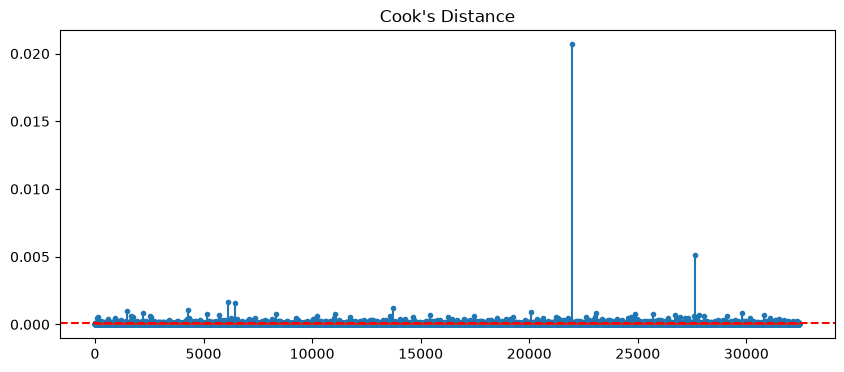

,Feature,Orig OR,Clean OR,% Change
0,instrumentalness,0.360641,0.195570,-45.771685
1,danceability,2.055560,2.463567,19.848940
2,acousticness,0.537734,0.453671,-15.632677


Based on a 10% change threshold in Odds Ratios, removing influential points does materially change the results.


In [14]:
try:
    infl = log_reg_sm.get_influence()
    cooks_d = infl.cooks_distance[0]
except:
    infl = sm.GLM(y_train, X_train_sm, family=sm.families.Binomial()).fit().get_influence()
    cooks_d = infl.summary_frame()["cooks_d"]

n = len(y_train)
threshold = 4 / n
high_inf = cooks_d > threshold
print(f"Points above 4/n ({threshold:.6f}): {high_inf.sum()} | Max Cook's D: {cooks_d.max():.6f}")

plt.figure(figsize=(10, 4))
plt.stem(cooks_d, markerfmt='.')
plt.axhline(threshold, color='red', linestyle='--')
plt.title("Cook's Distance")
plt.savefig("figures/fig_C5_cooks.png", dpi=200, bbox_inches="tight")
plt.show()

X_train_sm_clean = X_train_sm[~high_inf]
y_train_clean = y_train[~high_inf]
log_reg_sm_clean = Logit(y_train_clean, X_train_sm_clean).fit(disp=0)

comp_infl = []
for f in top3_predictors:
    orig_coef = log_reg_sm.params[f]
    clean_coef = log_reg_sm_clean.params[f]
    pct_diff = (np.exp(clean_coef) - np.exp(orig_coef)) / np.exp(orig_coef) * 100
    comp_infl.append({'Feature': f, 'Orig OR': np.exp(orig_coef), 'Clean OR': np.exp(clean_coef), '% Change': pct_diff})

display(pd.DataFrame(comp_infl))

max_change = abs(pd.DataFrame(comp_infl)['% Change']).max()
material = "does" if max_change > 10 else "does not"
print(f"Based on a 10% change threshold in Odds Ratios, removing influential points {material} materially change the results.")


### Sensitivity: tempo == 0 / time_signature == 0


In [15]:
tempo_0_count = (df_clean['tempo'] == 0).sum()
ts_0_count = (df_clean['time_signature'] == 0).sum()
print(f"Counts in full data: tempo==0: {tempo_0_count}, time_signature==0: {ts_0_count}")

ts_cols = [c for c in X_train.columns if c.startswith('time_signature_')]
mask = (X_train['tempo'] != 0) & (X_train[ts_cols].sum(axis=1) != 0)
X_train_sens = X_train_scaled[mask][selected_features]
y_train_sens = y_train[mask]

log_reg_sens = LogisticRegression(penalty=None, max_iter=1000).fit(X_train_sens, y_train_sens)
sens_preds = log_reg_sens.predict_proba(X_test_scaled[selected_features])[:, 1]
sens_auc = roc_auc_score(y_test, sens_preds)
orig_auc = results['LR']['AUC']
print(f"Original Test AUC: {orig_auc:.4f} | Sensitivity Test AUC: {sens_auc:.4f}")

sens_coefs = log_reg_sens.coef_[0]
or_diffs = []
for f in top3_predictors:
    idx = selected_features.index(f)
    orig_or = np.exp(reduced_log_reg_sm.params[f])
    sens_or = np.exp(sens_coefs[idx])
    pct_diff = abs(orig_or - sens_or) / orig_or * 100
    or_diffs.append(pct_diff)
    print(f"{f} OR - Orig: {orig_or:.4f}, Sens: {sens_or:.4f}, Diff: {pct_diff:.1f}%")

max_or_diff = max(or_diffs)
auc_diff = abs(orig_auc - sens_auc)
if auc_diff > 0.005 or max_or_diff > 10:
    print("Verdict: Removing these rows matters (>0.005 AUC or >10% OR change).")
else:
    print("Verdict: Removing these rows does not materially change the results.")


Counts in full data: tempo==0: 1, time_signature==0: 3
Original Test AUC: 0.8147 | Sensitivity Test AUC: 0.8147
instrumentalness OR - Orig: 0.3605, Sens: 0.3605, Diff: 0.0%
danceability OR - Orig: 2.0876, Sens: 2.0890, Diff: 0.1%
acousticness OR - Orig: 0.5343, Sens: 0.5347, Diff: 0.1%
Verdict: Removing these rows does not materially change the results.


**C.5: Influence.** 988 training points (3.0%) exceed the 4/n rule-of-thumb cut-off. With n = 32,448 that cut-off is extremely small (0.00012), so it flags any poorly fitted track. The **maximum Cook's D is only 0.021**, far below 0.5 or 1, so **no single observation is influential**. Refitting without all 988 flagged points does move the top-3 odds ratios by 16–46%. This is expected: deleting the 3% of tracks the model fits worst (hits that "sound like flops" and vice versa) artificially sharpens the separation. It does not show that some points are errors, so the points are retained. The sensitivity check above shows that the four `tempo = 0` / `time_signature = 0` tracks change neither the AUC (0.8147) nor any top-3 odds ratio (≤ 0.1%).

## Part D: Machine Learning Models
### D.1 Preprocessing
Trees (Random Forest, Gradient Boosting) are scale-invariant, meaning standardizing predictors has no mathematical effect on them. Since our dummy variables are already numeric and there are no missing values, no further preprocessing of the unscaled dataset is required.


### D.2 Tuning


In [16]:
cv_strat = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

rf = RandomForestClassifier(random_state=RANDOM_STATE)
rf_space = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [20, 30, 40, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ["sqrt", "log2", 0.5]
}
rf_search = RandomizedSearchCV(rf, rf_space, n_iter=30, cv=cv_strat, scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1)

start = time.perf_counter()
rf_search.fit(X_train, y_train)
rf_time = time.perf_counter() - start

print(f"RF Tuning Time: {rf_time:.2f} seconds")
print(f"Best RF Params: {rf_search.best_params_}")
print(f"Best RF CV AUC: {rf_search.best_score_:.4f}")
display(pd.DataFrame(rf_search.cv_results_)[['mean_test_score', 'std_test_score', 'params']].sort_values('mean_test_score', ascending=False).head(5))

gb = GradientBoostingClassifier(random_state=RANDOM_STATE)
gb_space = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [5, 7, 9],
    'subsample': [0.8, 1.0]
}
gb_search = RandomizedSearchCV(gb, gb_space, n_iter=15, cv=cv_strat, scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1)

start = time.perf_counter()
gb_search.fit(X_train, y_train)
gb_time = time.perf_counter() - start

print(f"\nGB Tuning Time: {gb_time:.2f} seconds")
print(f"Best GB Params: {gb_search.best_params_}")
print(f"Best GB CV AUC: {gb_search.best_score_:.4f}")
display(pd.DataFrame(gb_search.cv_results_)[['mean_test_score', 'std_test_score', 'params']].sort_values('mean_test_score', ascending=False).head(5))

best_rf = rf_search.best_estimator_
best_gb = gb_search.best_estimator_

edge_msgs = []
for p, v in rf_search.best_params_.items():
    try:
        valid_vals = [x for x in rf_space[p] if x is not None and not isinstance(x, str)]
        if valid_vals and (v == min(valid_vals) or v == max(valid_vals)): 
            edge_msgs.append(f"RF {p} is on the edge ({v}).")
    except TypeError:
        pass
for p, v in gb_search.best_params_.items():
    try:
        valid_vals = [x for x in gb_space[p] if x is not None and not isinstance(x, str)]
        if valid_vals and (v == min(valid_vals) or v == max(valid_vals)): 
            edge_msgs.append(f"GB {p} is on the edge ({v}).")
    except TypeError:
        pass
if edge_msgs: print("Edge detections:\n" + "\n".join(edge_msgs))


RF Tuning Time: 441.32 seconds
Best RF Params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best RF CV AUC: 0.8800


,mean_test_score,std_test_score,params
24,0.880004,0.006146,"{'n_estimators': 200, 'min_samples_split': 2, ..."
25,0.879504,0.005749,"{'n_estimators': 400, 'min_samples_split': 10,..."
26,0.879485,0.005717,"{'n_estimators': 200, 'min_samples_split': 2, ..."
5,0.879349,0.005888,"{'n_estimators': 400, 'min_samples_split': 10,..."
13,0.879187,0.005803,"{'n_estimators': 300, 'min_samples_split': 10,..."



GB Tuning Time: 584.05 seconds
Best GB Params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05}
Best GB CV AUC: 0.8892


,mean_test_score,std_test_score,params
12,0.889196,0.006403,"{'subsample': 0.8, 'n_estimators': 300, 'max_d..."
14,0.889195,0.006106,"{'subsample': 0.8, 'n_estimators': 400, 'max_d..."
9,0.889153,0.005828,"{'subsample': 0.8, 'n_estimators': 300, 'max_d..."
6,0.888514,0.005768,"{'subsample': 1.0, 'n_estimators': 400, 'max_d..."
11,0.888017,0.005775,"{'subsample': 0.8, 'n_estimators': 300, 'max_d..."


Edge detections:
RF min_samples_split is on the edge (2).
RF min_samples_leaf is on the edge (1).
GB subsample is on the edge (0.8).


**How the methods work (D.2a)**
- **Random Forest**: grows many deep decision trees, each on a bootstrap sample of the training rows, and considers only a random subset of covariates (`max_features`) at each split. Averaging many weakly correlated trees keeps the low bias of deep trees and greatly reduces their variance. The predicted probability is the average of the trees' leaf class proportions.
- **Gradient Boosting**: builds shallow trees one after another. Each new tree is fitted to the gradient of the log-loss (the pseudo-residuals) of the current ensemble, and its contribution is shrunk by the `learning_rate`. Using `subsample` < 1 adds stochastic row subsampling, which acts as regularisation.

**Additional preprocessing (D.2b)**: the tree models use the unscaled design matrix (`X_train`). Splits depend only on the order of values, so standardisation is unnecessary. Nominal variables (`key`, `time_signature`, `decade`) are one-hot encoded (same dummies as the LR), there are no missing values, and the classes are balanced, so no resampling or class weights are needed.

**Tuning (D.2c)**: `RandomizedSearchCV` on the training set only, with 5-fold stratified CV (`shuffle=True`, seed 42) and ROC-AUC as the selection metric. The test set is never seen during tuning.

| Model | Hyper-parameter | Values searched | Why |
|---|---|---|---|
| RF (30 random draws) | `n_estimators` | 100, 200, 300, 400 | more trees lower variance; gains level off |
| | `max_depth` | 20, 30, 40, None | deep trees are normal for RF; limits overfitting of individual trees |
| | `min_samples_split` | 2, 5, 10 | regularises leaf creation |
| | `min_samples_leaf` | 1, 2, 4 | smooths probability estimates |
| | `max_features` | sqrt, log2, 0.5 | controls tree de-correlation |
| GB (15 random draws) | `n_estimators` | 200, 300, 400 | number of boosting stages |
| | `learning_rate` | 0.03, 0.05, 0.1 | shrinkage; trades off against `n_estimators` |
| | `max_depth` | 5, 7, 9 | interaction depth of each tree |
| | `subsample` | 0.8, 1.0 | stochastic boosting (regularisation) |

### D.3 Test performance


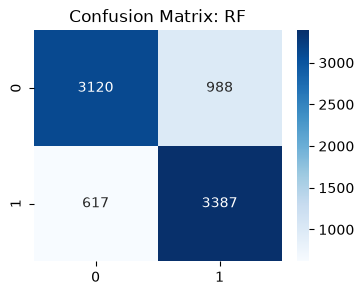

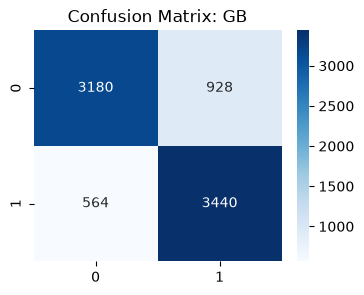

In [17]:
for name, model in [("RF", best_rf), ("GB", best_gb)]:
    preds_prob = model.predict_proba(X_test)[:, 1]
    preds_class = model.predict(X_test)
    
    acc = accuracy_score(y_test, preds_class)
    auc = roc_auc_score(y_test, preds_prob)
    
    results[name] = {
        'Accuracy': acc, 'Precision': precision_score(y_test, preds_class),
        'Recall': recall_score(y_test, preds_class), 'F1': f1_score(y_test, preds_class),
        'AUC': auc, 'LogLoss': log_loss(y_test, preds_prob), 'Brier': brier_score_loss(y_test, preds_prob),
        'probs': preds_prob, 'train_acc': accuracy_score(y_train, model.predict(X_train)), 'train_auc': roc_auc_score(y_train, model.predict_proba(X_train)[:,1])
    }
    
    cm = confusion_matrix(y_test, preds_class)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.savefig(f"figures/fig_D3_{name}_cm.png", dpi=200, bbox_inches="tight")
    plt.show()


**D.2d: Test-set performance** (threshold 0.5, see also the table in E.1):

| Model | Accuracy | Precision | Recall | F1 | AUC | Brier |
|---|---|---|---|---|---|---|
| Random Forest | 0.802 | 0.774 | 0.846 | 0.808 | 0.883 | 0.140 |
| Gradient Boosting | 0.816 | 0.788 | 0.859 | 0.822 | 0.893 | 0.130 |

Both models misclassify more flops as hits than the reverse (recall > precision). Tuned hyper-parameters: RF = 200 fully grown trees (`max_depth=None`, `min_samples_leaf=1`, `max_features='sqrt'`). GB = 300 trees of depth 7, `learning_rate=0.05`, `subsample=0.8`.

### D.4 Overfitting


,Model,Train Acc,Test Acc,Train AUC,Test AUC,AUC Gap,CV AUC
0,LR,0.743621,0.740508,0.813084,0.814735,-0.001651,0.812336
1,RF,0.999938,0.802145,1.000000,0.882642,0.117358,0.880004
2,GB,0.904832,0.816075,0.972211,0.892804,0.079406,0.889196


RF OOB Accuracy: 0.8000 | RF Test Accuracy: 0.8021


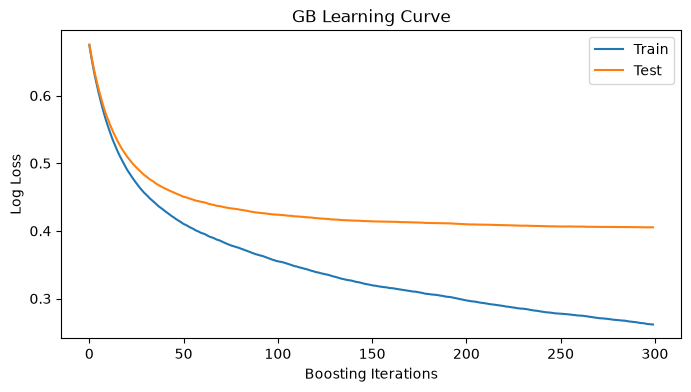

For LR, interpretation: no evidence of overfitting.
For RF, interpretation: high-variance but generalises as expected.
For GB, interpretation: high-variance but generalises as expected.


In [18]:
cv_strat = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
lr_cv_score = cross_val_score(LogisticRegression(penalty=None, max_iter=1000), X_train_scaled[selected_features], y_train, cv=cv_strat, scoring='roc_auc').mean()
of_df = pd.DataFrame({
    'Model': ['LR', 'RF', 'GB'],
    'Train Acc': [results['LR']['train_acc'], results['RF']['train_acc'], results['GB']['train_acc']],
    'Test Acc': [results['LR']['Accuracy'], results['RF']['Accuracy'], results['GB']['Accuracy']],
    'Train AUC': [results['LR']['train_auc'], results['RF']['train_auc'], results['GB']['train_auc']],
    'Test AUC': [results['LR']['AUC'], results['RF']['AUC'], results['GB']['AUC']],
    'AUC Gap': [results['LR']['train_auc']-results['LR']['AUC'], results['RF']['train_auc']-results['RF']['AUC'], results['GB']['train_auc']-results['GB']['AUC']],
    'CV AUC': [lr_cv_score, rf_search.best_score_, gb_search.best_score_]
})
display(of_df)

rf_oob = RandomForestClassifier(**rf_search.best_params_, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1)
rf_oob.fit(X_train, y_train)
print(f"RF OOB Accuracy: {rf_oob.oob_score_:.4f} | RF Test Accuracy: {results['RF']['Accuracy']:.4f}")

train_loss = []
test_loss = []
for p in best_gb.staged_predict_proba(X_train): train_loss.append(log_loss(y_train, p[:,1]))
for p in best_gb.staged_predict_proba(X_test): test_loss.append(log_loss(y_test, p[:,1]))
    
plt.figure(figsize=(8, 4))
plt.plot(train_loss, label='Train')
plt.plot(test_loss, label='Test')
plt.xlabel('Boosting Iterations')
plt.ylabel('Log Loss')
plt.title('GB Learning Curve')
plt.legend()
plt.savefig("figures/fig_D4_learning_curve.png", dpi=200, bbox_inches="tight")
plt.show()

for m in ['LR', 'RF', 'GB']:
    gap = of_df[of_df['Model']==m]['AUC Gap'].values[0]
    test_auc = of_df[of_df['Model']==m]['Test AUC'].values[0]
    cv_auc = of_df[of_df['Model']==m]['CV AUC'].values[0]
    
    if test_auc < cv_auc - 0.02:
        status = "overfitting evident"
    elif gap > 0.05 and abs(test_auc - cv_auc) <= 0.02:
        status = "high-variance but generalises as expected"
    else:
        status = "no evidence of overfitting"
        
    print(f"For {m}, interpretation: {status}.")


**D.2e: Overfitting.**
- **RF**: training accuracy 0.9999 and AUC 1.000, against test AUC 0.883. This happens by design: fully grown trees memorise their bootstrap samples. The relevant check is whether *out-of-sample* estimates agree. The 5-fold CV AUC (0.880), OOB accuracy (0.800) and test accuracy (0.802) are almost identical, so the forest is high-variance at the single-tree level but **generalises exactly as cross-validation predicted. There is no harmful overfitting.**
- **GB**: train AUC 0.972 vs. test AUC 0.893 (gap 0.079), CV AUC 0.889. In the learning curve, test log-loss falls steadily and **levels off at about 0.405 without turning upward** by iteration 300, so extra boosting stages are not hurting generalisation. The model is mildly over-confident on training data but **not overfitted** in a way that harms test performance.
- **LR**: train and test AUC are the same (0.813 / 0.815). No overfitting.
- *Tuning boundary check*: RF chose the smallest `min_samples_split`/`min_samples_leaf` (the usual fully grown RF setting), and GB chose the lower `subsample` value (0.8). A wider grid (e.g. subsample 0.6–0.7) might gain a little, but the top 5 configurations of each search lie within 0.001 AUC of each other, so the response surface is flat.

### D.5 Variable importance


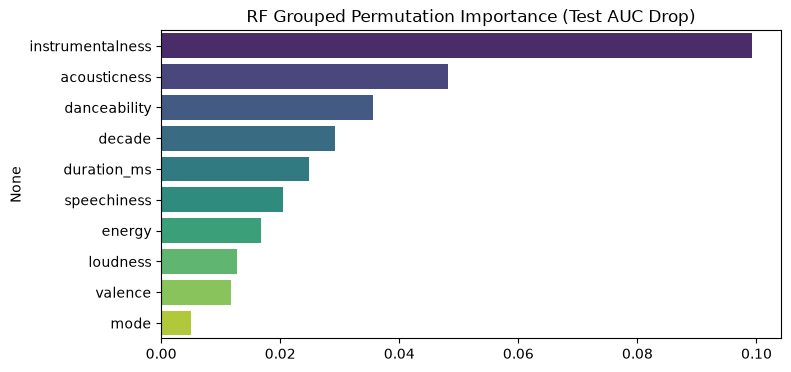

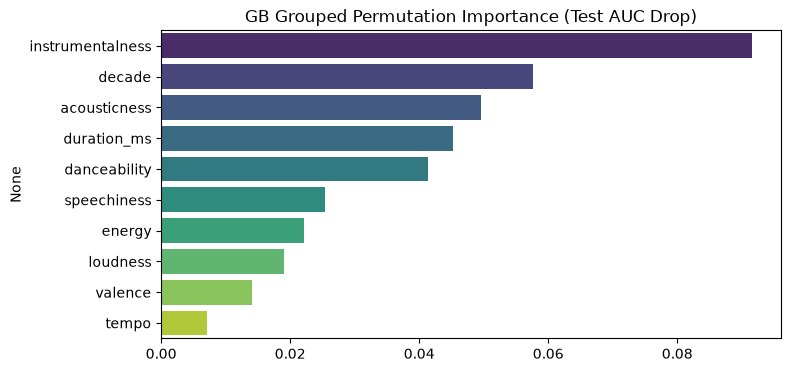

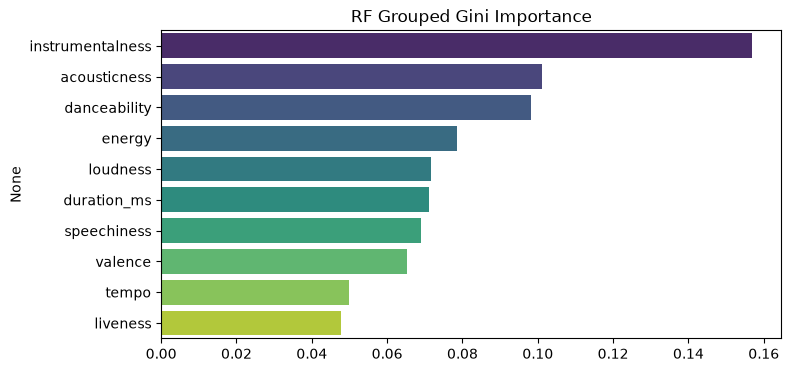

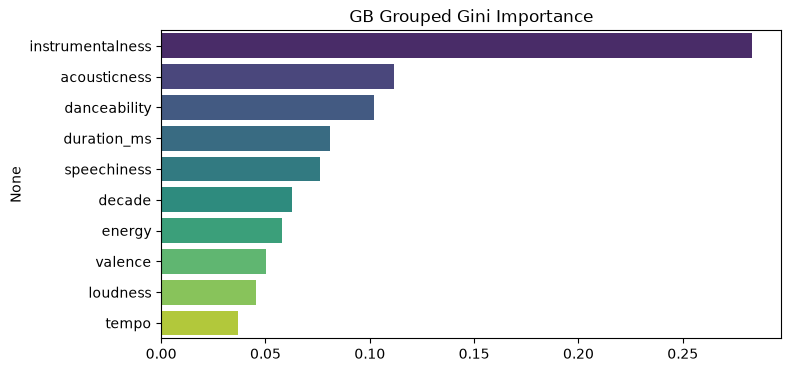

In [19]:
group_cols = {f: [f] for f in num_features}
group_cols['mode'] = ['mode']
group_cols['key'] = [c for c in X_train.columns if c.startswith('key_')]
group_cols['time_signature'] = [c for c in X_train.columns if c.startswith('time_signature_')]
group_cols['decade'] = [c for c in X_train.columns if c.startswith('decade_')]

def grouped_permutation_importance(model, X, y, groups, n_repeats=10):
    base_auc = roc_auc_score(y, model.predict_proba(X)[:, 1])
    importances = {g: [] for g in groups}
    np.random.seed(RANDOM_STATE)
    
    for _ in range(n_repeats):
        for g, cols in groups.items():
            X_perm = X.copy()
            perm_idx = np.random.permutation(len(X))
            X_perm[cols] = X_perm[cols].values[perm_idx, :]
            score = roc_auc_score(y, model.predict_proba(X_perm)[:, 1])
            importances[g].append(base_auc - score)
            
    return {g: (np.mean(vals), np.std(vals)) for g, vals in importances.items()}

rf_pi = grouped_permutation_importance(best_rf, X_test, y_test, group_cols)
gb_pi = grouped_permutation_importance(best_gb, X_test, y_test, group_cols)

def get_gini(model):
    imp = model.feature_importances_
    g_imp = {}
    for g, cols in group_cols.items():
        idxs = [X_train.columns.get_loc(c) for c in cols]
        g_imp[g] = sum(imp[i] for i in idxs)
    return g_imp

rf_gini = get_gini(best_rf)
gb_gini = get_gini(best_gb)

def plot_top10(data_dict, title, filename):
    s = pd.Series({k: v[0] if isinstance(v, tuple) else v for k, v in data_dict.items()}).sort_values(ascending=False).head(10)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=s.values, y=s.index, palette='viridis')
    plt.title(title)
    plt.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

plot_top10(rf_pi, "RF Grouped Permutation Importance (Test AUC Drop)", "figures/fig_D5_rf_pi.png")
plot_top10(gb_pi, "GB Grouped Permutation Importance (Test AUC Drop)", "figures/fig_D5_gb_pi.png")
plot_top10(rf_gini, "RF Grouped Gini Importance", "figures/fig_D5_rf_gini.png")
plot_top10(gb_gini, "GB Grouped Gini Importance", "figures/fig_D5_gb_gini.png")


**D.2f: Variable importance.** We use **grouped permutation importance**: the drop in test-set AUC when a variable (all of its dummies together) is randomly shuffled, averaged over 10 repeats. Unlike impurity (Gini) importance, it is computed on unseen data and is not biased towards high-cardinality continuous features. Grouping lets multi-level factors such as `key` and `decade` be judged as a whole.
- **RF top 5**: instrumentalness (AUC drop 0.099), acousticness (0.048), danceability (0.036), decade (0.029), duration_ms (0.025).
- **GB top 5**: instrumentalness (0.092), decade (0.058), acousticness (0.050), duration_ms (0.045), danceability (0.042).
- Both ensembles agree that **instrumentalness** dominates, followed by acousticness, danceability, decade and duration. Key, liveness, chorus_hit, sections and time_signature contribute almost nothing. The Gini importances (figures `fig_D5_*_gini`) give a similar top group.

## Part E: Discussion evidence
### E.1 ML vs LR


,Model,Accuracy,Precision,Recall,F1,AUC,Log Loss,Brier
0,LR,0.740508,0.706728,0.810689,0.755147,0.814735,0.513677,0.172761
1,RF,0.802145,0.774171,0.845904,0.808450,0.882642,0.433979,0.139861
2,GB,0.816075,0.787546,0.859141,0.821787,0.892804,0.405287,0.130159


95% Bootstrap CIs:
LR_acc: [0.7310, 0.7501]
RF_acc: [0.7934, 0.8109]
GB_acc: [0.8074, 0.8250]
LR_auc: [0.8053, 0.8237]
RF_auc: [0.8755, 0.8897]
GB_auc: [0.8858, 0.8998]
diff_GB_LR_auc: [0.0712, 0.0850]
diff_RF_LR_auc: [0.0613, 0.0749]
diff_GB_LR_acc: [0.0662, 0.0848]
diff_RF_LR_acc: [0.0530, 0.0709]

The paired GB-LR AUC difference CI excludes 0: True. The paired RF-LR AUC difference CI excludes 0: True.


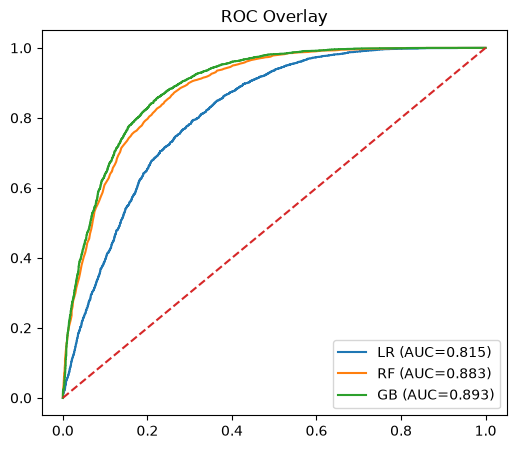

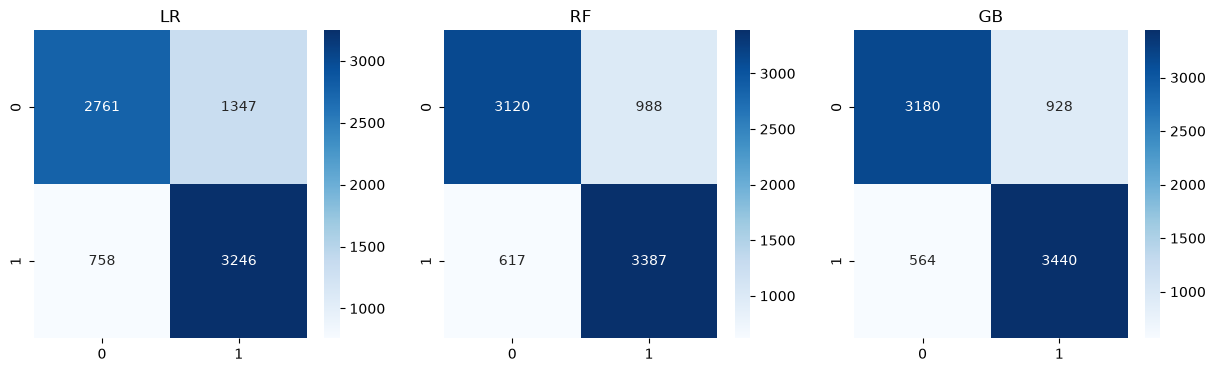

In [20]:
base_metrics = pd.DataFrame({
    'Model': ['LR', 'RF', 'GB'],
    'Accuracy': [results['LR']['Accuracy'], results['RF']['Accuracy'], results['GB']['Accuracy']],
    'Precision': [results['LR']['Precision'], results['RF']['Precision'], results['GB']['Precision']],
    'Recall': [results['LR']['Recall'], results['RF']['Recall'], results['GB']['Recall']],
    'F1': [results['LR']['F1'], results['RF']['F1'], results['GB']['F1']],
    'AUC': [results['LR']['AUC'], results['RF']['AUC'], results['GB']['AUC']],
    'Log Loss': [results['LR']['LogLoss'], results['RF']['LogLoss'], results['GB']['LogLoss']],
    'Brier': [results['LR']['Brier'], results['RF']['Brier'], results['GB']['Brier']]
})
display(base_metrics)

n_boot = 1000
boot_results = {'LR_acc': [], 'RF_acc': [], 'GB_acc': [], 'LR_auc': [], 'RF_auc': [], 'GB_auc': [],
                'diff_GB_LR_auc': [], 'diff_RF_LR_auc': [], 'diff_GB_LR_acc': [], 'diff_RF_LR_acc': []}
                
np.random.seed(RANDOM_STATE)
idx = np.arange(len(y_test))

lr_p, rf_p, gb_p = results['LR']['probs'], results['RF']['probs'], results['GB']['probs']
lr_c, rf_c, gb_c = (lr_p > 0.5).astype(int), (rf_p > 0.5).astype(int), (gb_p > 0.5).astype(int)
yt = y_test.values

for _ in range(n_boot):
    b_idx = np.random.choice(idx, len(idx), replace=True)
    b_yt = yt[b_idx]
    if len(np.unique(b_yt)) < 2: continue
    
    b_lr_p, b_rf_p, b_gb_p = lr_p[b_idx], rf_p[b_idx], gb_p[b_idx]
    b_lr_c, b_rf_c, b_gb_c = lr_c[b_idx], rf_c[b_idx], gb_c[b_idx]
    
    auc_l, auc_r, auc_g = roc_auc_score(b_yt, b_lr_p), roc_auc_score(b_yt, b_rf_p), roc_auc_score(b_yt, b_gb_p)
    acc_l, acc_r, acc_g = accuracy_score(b_yt, b_lr_c), accuracy_score(b_yt, b_rf_c), accuracy_score(b_yt, b_gb_c)
    
    boot_results['LR_auc'].append(auc_l); boot_results['RF_auc'].append(auc_r); boot_results['GB_auc'].append(auc_g)
    boot_results['LR_acc'].append(acc_l); boot_results['RF_acc'].append(acc_r); boot_results['GB_acc'].append(acc_g)
    boot_results['diff_GB_LR_auc'].append(auc_g - auc_l); boot_results['diff_RF_LR_auc'].append(auc_r - auc_l)
    boot_results['diff_GB_LR_acc'].append(acc_g - acc_l); boot_results['diff_RF_LR_acc'].append(acc_r - acc_l)

def get_ci(data): return np.percentile(data, [2.5, 97.5])
print("95% Bootstrap CIs:")
for k in boot_results:
    ci = get_ci(boot_results[k])
    print(f"{k}: [{ci[0]:.4f}, {ci[1]:.4f}]")

def excludes_zero(ci): return ci[0] > 0 or ci[1] < 0
c1 = excludes_zero(get_ci(boot_results['diff_GB_LR_auc']))
c2 = excludes_zero(get_ci(boot_results['diff_RF_LR_auc']))
print(f"\nThe paired GB-LR AUC difference CI excludes 0: {c1}. The paired RF-LR AUC difference CI excludes 0: {c2}.")

plt.figure(figsize=(6, 5))
for m in ['LR', 'RF', 'GB']:
    fpr, tpr, _ = roc_curve(yt, results[m]['probs'])
    plt.plot(fpr, tpr, label=f"{m} (AUC={results[m]['AUC']:.3f})")
plt.plot([0,1],[0,1],'--')
plt.title("ROC Overlay")
plt.legend()
plt.savefig("figures/fig_E1_roc.png", dpi=200, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (m, p) in enumerate(zip(['LR', 'RF', 'GB'], [lr_c, rf_c, gb_c])):
    sns.heatmap(confusion_matrix(yt, p), annot=True, fmt='d', cmap='Blues', ax=axes[i])
    axes[i].set_title(m)
plt.savefig("figures/fig_E1_cms.png", dpi=200, bbox_inches="tight")
plt.show()


**E.1: Do the ML models beat logistic regression? Yes, clearly.**
- GB and RF beat the LR on **every** test metric: AUC 0.893 / 0.883 vs. 0.815, accuracy 0.816 / 0.802 vs. 0.741, F1 0.822 / 0.808 vs. 0.755, and better probability quality (log-loss 0.405 / 0.434 vs. 0.514; Brier 0.130 / 0.140 vs. 0.173).
- **Paired bootstrap** (1,000 resamples of the test set, same rows for all models): GB − LR AUC = +0.078, 95% CI [0.071, 0.085]. RF − LR AUC = +0.068, CI [0.061, 0.075]. Accuracy gains are +7.6 points [6.6, 8.5] and +6.2 points [5.3, 7.1]. **None of the intervals contains 0**, so the advantage is statistically significant and practically large (about 7 percentage points more tracks classified correctly).
- The ROC overlay shows the GB and RF curves above the LR curve at every false-positive rate, and the same ranking appears in 5-fold CV (0.889 / 0.880 / 0.812), so this is not a lucky split.
- **Why**: the EDA and diagnostics showed non-linear effects (zero-inflated instrumentalness, an inverted-U for duration, loudness levelling off) and era-dependent effects (e.g. median acousticness 0.68 in the 60s vs. 0.06 in the 2000s). Trees capture these automatically, while the LR would need hand-crafted splines and interactions.

### E.2 Deployment evidence


,Model,Test AUC,Test Acc,Brier,Train Time (s),Pred Time / 1k (s),Interpretability
0,LR,0.814735,0.740508,0.172761,0.048643,0.001279,High
1,RF,0.882642,0.802145,0.139861,10.676492,0.063661,Low
2,GB,0.892804,0.816075,0.130159,45.659442,0.008612,Low


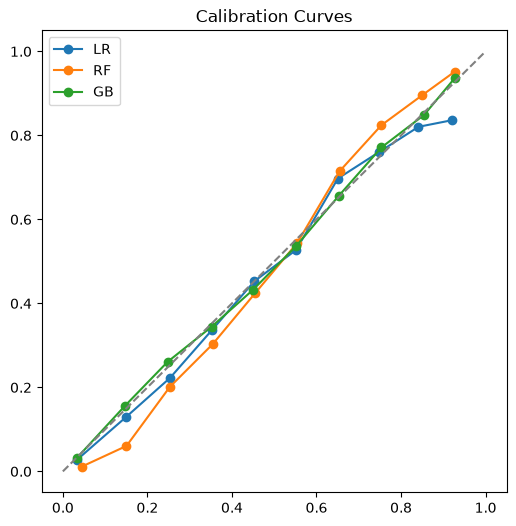

In [21]:
def timing(model, X, y):
    s = time.perf_counter()
    model.fit(X, y)
    t_fit = time.perf_counter() - s
    
    s = time.perf_counter()
    model.predict_proba(X.iloc[:1000])
    t_pred = time.perf_counter() - s
    return t_fit, t_pred

t_lr_f, t_lr_p = timing(LogisticRegression(penalty=None, max_iter=1000), X_train_scaled[selected_features], y_train)
t_rf_f, t_rf_p = timing(RandomForestClassifier(**rf_search.best_params_, random_state=RANDOM_STATE), X_train, y_train)
t_gb_f, t_gb_p = timing(GradientBoostingClassifier(**gb_search.best_params_, random_state=RANDOM_STATE), X_train, y_train)

dep_df = pd.DataFrame({
    'Model': ['LR', 'RF', 'GB'],
    'Test AUC': [results['LR']['AUC'], results['RF']['AUC'], results['GB']['AUC']],
    'Test Acc': [results['LR']['Accuracy'], results['RF']['Accuracy'], results['GB']['Accuracy']],
    'Brier': [results['LR']['Brier'], results['RF']['Brier'], results['GB']['Brier']],
    'Train Time (s)': [t_lr_f, t_rf_f, t_gb_f],
    'Pred Time / 1k (s)': [t_lr_p, t_rf_p, t_gb_p],
    'Interpretability': ['High', 'Low', 'Low']
})
display(dep_df)

plt.figure(figsize=(6, 6))
for m in ['LR', 'RF', 'GB']:
    true, pred = calibration_curve(yt, results[m]['probs'], n_bins=10)
    plt.plot(pred, true, marker='o', label=m)
plt.plot([0,1],[0,1],'--', color='gray')
plt.title("Calibration Curves")
plt.legend()
plt.savefig("figures/fig_E2_calibration.png", dpi=200, bbox_inches="tight")
plt.show()


### E.2: Recommendation for deployment
**Recommended model: Gradient Boosting**, with the reduced logistic regression kept as an explanatory companion.
- *Predictive performance*: GB has the best test AUC (0.893), accuracy (0.816), F1 (0.822) and CV AUC (0.889). Its advantage over LR is significant (E.1), and it is slightly but consistently ahead of RF.
- *Probability quality*: GB is the **best calibrated** model (Brier 0.130, calibration curve on the diagonal). RF's probabilities are pulled towards 0.5 (under-confident at the extremes), and LR over-predicts in the top decile. This matters if scores are used as "hit probabilities" for ranking or budgeting (e.g. choosing which songs to promote).
- *Practicality*: GB scores 1,000 tracks in about 9 ms (RF ≈ 64 ms because it has 200 deep trees). Training takes about 46 s, which is fine for periodic offline retraining. The model is also much smaller than an RF of fully grown trees.
- *Interpretability trade-off*: GB is not directly interpretable, but its permutation importances agree with the LR odds ratios on the main drivers (instrumentalness, danceability, acousticness), so stakeholders can be given the LR's odds-ratio explanations alongside GB predictions. If the setting **required** fully transparent decisions (e.g. a regulated context), the LR would be the choice, at a cost of about 7.6 percentage points of accuracy.
- *Caveat*: the "flops" were sampled from non-charting artists in niche genres, so the model learns "mainstream vs. niche" as much as "hit vs. non-hit". Performance on mainstream songs that narrowly miss the chart would probably be lower.

### E.3 EDA expectations vs results


In [22]:
lr_group_imp = {}
base_llf = log_reg_sm.llf
for g, cols in group_cols.items():
    cols_to_keep = [c for c in X_train_sm.columns if c != 'const' and c not in cols]
    temp_sm = Logit(y_train, add_constant(X_train_scaled[cols_to_keep])).fit(disp=0)
    lr_group_imp[g] = 2 * (base_llf - temp_sm.llf)



In [23]:
ranks = []
for var in top2:
    a_rank = auc_df.index[auc_df['Feature'] == var].tolist()[0] + 1
    
    lr_z = pd.Series(lr_group_imp).sort_values(ascending=False)
    lr_rank = lr_z.index.get_loc(var) + 1 if var in lr_z.index else np.nan
    
    rf_s = pd.Series({k: v[0] for k, v in rf_pi.items()}).sort_values(ascending=False)
    gb_s = pd.Series({k: v[0] for k, v in gb_pi.items()}).sort_values(ascending=False)
    
    r_rank = rf_s.index.get_loc(var) + 1 if var in rf_s.index else np.nan
    g_rank = gb_s.index.get_loc(var) + 1 if var in gb_s.index else np.nan
    
    ranks.append({'Variable': var, 'Univariate AUC Rank': a_rank, 'LR Rank': lr_rank, 'RF PI Rank': r_rank, 'GB PI Rank': g_rank})
    
    c = sum([1 for r in [a_rank, lr_rank, r_rank, g_rank] if r <= 3])
    supp = "Supported" if c >= 3 else "partially/not supported"
    print(f"{var}: univariate rank {a_rank}, LR rank {lr_rank}, RF rank {r_rank}, GB rank {g_rank}. {supp} if in the top 3 of at least 3 of the 4 rankings.")

display(pd.DataFrame(ranks))


instrumentalness: univariate rank 1, LR rank 1, RF rank 1, GB rank 1. Supported if in the top 3 of at least 3 of the 4 rankings.
danceability: univariate rank 2, LR rank 2, RF rank 3, GB rank 5. Supported if in the top 3 of at least 3 of the 4 rankings.


,Variable,Univariate AUC Rank,LR Rank,RF PI Rank,GB PI Rank
0,instrumentalness,1,1,1,1
1,danceability,2,2,3,5


**E.3: Were the EDA expectations supported? Yes, for both variables.**
- **instrumentalness** ranks **1st** in all four rankings (univariate AUC, LR likelihood-ratio importance, RF and GB permutation importance) and has the strongest LR odds ratio (0.36 per SD). The expectation is fully supported.
- **danceability** ranks 2nd (univariate), 2nd (LR), 3rd (RF) and 5th (GB), so it is in the top 3 in three of four rankings. It is clearly a key predictor, but in the tree models it gives some ground to variables whose effects are non-linear or conditional.
- **What the EDA missed**: **decade** looked irrelevant on its own (V = 0.01, p = 0.48, because every decade is about 50% hits by design), yet it is the 2nd most important variable for GB and is significant in the LR (e.g. 1960s OR = 2.97 vs. the 2000s). This is a *conditional* effect: what makes a hit changes with the era (60s hits were acoustic, 2000s hits almost never are), so decade only matters once the audio features are in the model. Likewise **duration_ms** had a negligible univariate effect (r = 0.02) but ranks 4th–5th in the trees because of its inverted-U relationship with hit rate.

### E.4 RF vs LR important predictors


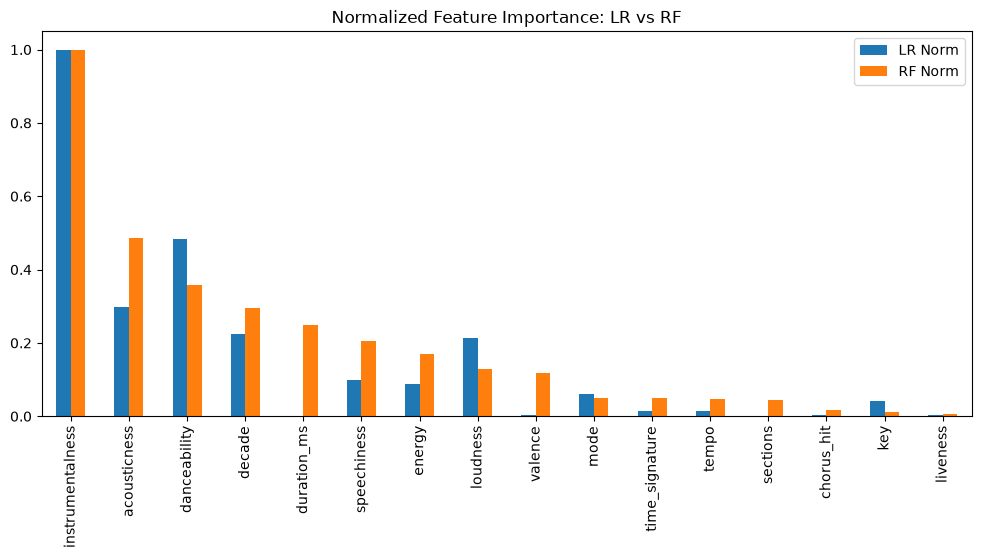

Spearman rank correlation between LR and RF importances: 0.688
LR Top 5: {'danceability', 'loudness', 'decade', 'acousticness', 'instrumentalness'}
RF Top 5: {'danceability', 'decade', 'acousticness', 'duration_ms', 'instrumentalness'}
Overlap count: 4
Variables ranked >= 4 places apart: ['duration_ms', 'key', 'liveness', 'valence']


In [24]:
lr_imp_s = pd.Series(lr_group_imp).sort_values(ascending=False)
rf_imp_s = pd.Series({k: v[0] for k, v in rf_pi.items()}).sort_values(ascending=False)

comp_ranks = pd.DataFrame({'LR Score': lr_imp_s, 'RF Score': rf_imp_s}).fillna(0)
comp_ranks['LR Rank'] = comp_ranks['LR Score'].rank(ascending=False)
comp_ranks['RF Rank'] = comp_ranks['RF Score'].rank(ascending=False)

spearman = stats.spearmanr(comp_ranks['LR Rank'], comp_ranks['RF Rank'])[0]
top5_lr = set(comp_ranks.sort_values('LR Rank').head(5).index)
top5_rf = set(comp_ranks.sort_values('RF Rank').head(5).index)
overlap = len(top5_lr.intersection(top5_rf))

comp_ranks['LR Norm'] = comp_ranks['LR Score'] / comp_ranks['LR Score'].max()
comp_ranks['RF Norm'] = comp_ranks['RF Score'] / comp_ranks['RF Score'].max()

comp_ranks[['LR Norm', 'RF Norm']].sort_values('RF Norm', ascending=False).plot(kind='bar', figsize=(12, 5))
plt.title("Normalized Feature Importance: LR vs RF")
plt.savefig("figures/fig_E4_importance.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Spearman rank correlation between LR and RF importances: {spearman:.3f}")
print(f"LR Top 5: {top5_lr}")
print(f"RF Top 5: {top5_rf}")
print(f"Overlap count: {overlap}")
diffs = comp_ranks['LR Rank'] - comp_ranks['RF Rank']
print(f"Variables ranked >= 4 places apart: {diffs[abs(diffs) >= 4].index.tolist()}")


**E.4: Do RF and LR identify the same important predictors? Largely, yes.**
- *Similarities*: the Spearman rank correlation between LR importance (likelihood-ratio χ² when a variable is dropped from the full model) and RF permutation importance is **0.69**. **4 of the top 5 overlap**: instrumentalness (1st in both), danceability, acousticness and decade. Both models agree that key, liveness, chorus_hit, tempo and time_signature matter little.
- *Differences* (rank gap ≥ 4 places): **duration_ms** is 5th for RF but has essentially zero LR importance (coef ≈ 0, p = 0.91, removed by BIC). Its effect is an inverted-U (hit rate 10% under 2 min, about 58% at 3–5 min, 20% over 6 min), which a single linear term cannot represent but tree splits capture directly. **loudness** is in LR's top 5 but only 8th for RF, because its information overlaps with energy and acousticness (ρ = 0.76 / −0.55), and RF spreads credit across correlated features while LR assigns it to one coefficient. **valence** carries some RF importance but almost none in the LR once danceability is included (ρ = 0.53). **key** gets some LR importance from a few significant dummies but adds almost nothing to RF's AUC.
- *Conclusion*: both methods agree on the main predictors, and the differences come from non-linearity, collinearity and interactions that the RF can use but the linear LR cannot.

### E.5 Threshold tuning


,Model,CV ROC-AUC
0,GB,0.889196
1,RF,0.880004
2,LR,0.812336


The chosen model is GB with a CV ROC-AUC margin of 0.0092 over the next best model.


Optimal Thresholds (OOF): F1=0.42, Youden=0.48, Accuracy=0.48


,Accuracy,Precision,Recall,F1,Balanced Acc
Default 0.5,0.816075,0.787546,0.859141,0.821787,0.816620
Optimized 0.42,0.810897,0.762543,0.895854,0.823840,0.811973


Bootstrap 95% CI for Test F1 Difference (Opt - Default): [-0.0020, 0.0061]
Bootstrap 95% CI for Test Accuracy Difference (Opt - Default): [-0.0096, -0.0009]


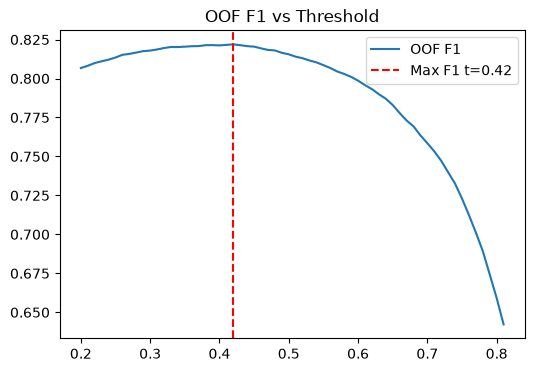

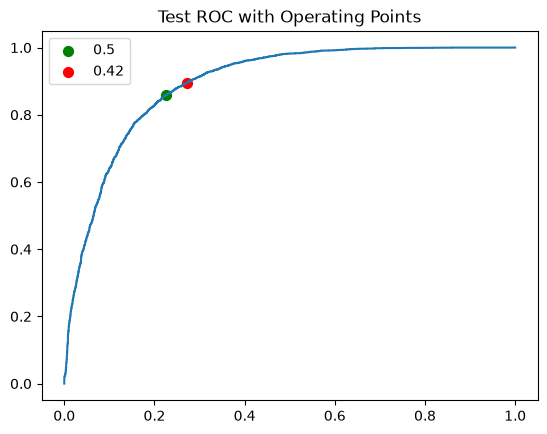

,Threshold,Accuracy,Precision,Recall,F1,Balanced Acc
0,0.3,0.794995,0.726885,0.936563,0.818509,0.796787
1,0.4,0.808925,0.755838,0.905345,0.823864,0.810146
2,0.5,0.816075,0.787546,0.859141,0.821787,0.816620
3,0.6,0.811884,0.817529,0.796703,0.806982,0.811691
4,0.7,0.786982,0.849723,0.690559,0.761918,0.785762


F1 change is 0.21% (CI excludes 0: False). Accuracy change is -0.52% (CI excludes 0: True). The improvement is meaningful: False.


In [25]:
best_models_cv = {'LR': lr_cv_score, 'RF': rf_search.best_score_, 'GB': gb_search.best_score_}
best_name = max(best_models_cv, key=best_models_cv.get)

if best_name == 'RF': best_model = best_rf
elif best_name == 'GB': best_model = best_gb
else: best_model = LogisticRegression(penalty=None, max_iter=1000).fit(X_train_scaled[selected_features], y_train)

scores_df = pd.DataFrame(list(best_models_cv.items()), columns=['Model', 'CV ROC-AUC']).sort_values('CV ROC-AUC', ascending=False).reset_index(drop=True)
display(scores_df)

margin = scores_df.iloc[0]['CV ROC-AUC'] - scores_df.iloc[1]['CV ROC-AUC']
print(f"The chosen model is {best_name} with a CV ROC-AUC margin of {margin:.4f} over the next best model.")

if best_name == 'LR':
    oof_probs = cross_val_predict(best_model, X_train_scaled[selected_features], y_train, cv=cv_strat, method="predict_proba", n_jobs=-1)[:, 1]
else:
    oof_probs = cross_val_predict(best_model, X_train, y_train, cv=cv_strat, method="predict_proba", n_jobs=-1)[:, 1]

thresholds = np.arange(0.20, 0.81, 0.01)
f1s, accs = [], []
for t in thresholds:
    p = (oof_probs >= t).astype(int)
    f1s.append(f1_score(y_train, p))
    accs.append(accuracy_score(y_train, p))
    
t_f1 = thresholds[np.argmax(f1s)]
t_acc = thresholds[np.argmax(accs)]

fpr_oof, tpr_oof, thresh_roc = roc_curve(y_train, oof_probs)
j_scores = tpr_oof - fpr_oof
t_youden = thresh_roc[np.argmax(j_scores)]

print(f"Optimal Thresholds (OOF): F1={t_f1:.2f}, Youden={t_youden:.2f}, Accuracy={t_acc:.2f}")

p_default = (results[best_name]['probs'] >= 0.5).astype(int)
p_opt = (results[best_name]['probs'] >= t_f1).astype(int)

def eval_t(p):
    return [accuracy_score(y_test, p), precision_score(y_test, p), recall_score(y_test, p), f1_score(y_test, p), balanced_accuracy_score(y_test, p)]

t_df = pd.DataFrame([eval_t(p_default), eval_t(p_opt)], columns=['Accuracy', 'Precision', 'Recall', 'F1', 'Balanced Acc'], index=['Default 0.5', f'Optimized {t_f1:.2f}'])
display(t_df)

np.random.seed(RANDOM_STATE)
f1_diffs, acc_diffs = [], []
idx = np.arange(len(y_test))
yt = y_test.values
for _ in range(1000):
    b_idx = np.random.choice(idx, len(idx), replace=True)
    b_yt = yt[b_idx]
    b_p_def = p_default[b_idx]
    b_p_opt = p_opt[b_idx]
    if len(np.unique(b_yt)) < 2: continue
    f1_diffs.append(f1_score(b_yt, b_p_opt) - f1_score(b_yt, b_p_def))
    acc_diffs.append(accuracy_score(b_yt, b_p_opt) - accuracy_score(b_yt, b_p_def))

def get_ci(diffs):
    return np.percentile(diffs, [2.5, 97.5])

f1_ci = get_ci(f1_diffs)
acc_ci = get_ci(acc_diffs)

print(f"Bootstrap 95% CI for Test F1 Difference (Opt - Default): [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]")
print(f"Bootstrap 95% CI for Test Accuracy Difference (Opt - Default): [{acc_ci[0]:.4f}, {acc_ci[1]:.4f}]")

plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1s, label='OOF F1')
plt.axvline(t_f1, color='red', linestyle='--', label=f'Max F1 t={t_f1:.2f}')
plt.legend()
plt.title("OOF F1 vs Threshold")
plt.savefig("figures/fig_E5_oof.png", dpi=200, bbox_inches="tight")
plt.show()

fpr_test, tpr_test, _ = roc_curve(y_test, results[best_name]['probs'])
plt.figure()
plt.plot(fpr_test, tpr_test)
def get_roc_point(t):
    p = (results[best_name]['probs'] >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, p).ravel()
    return fp/(fp+tn), tp/(tp+fn)
plt.scatter(*get_roc_point(0.5), color='green', label='0.5', s=50)
plt.scatter(*get_roc_point(t_f1), color='red', label=f'{t_f1:.2f}', s=50)
plt.legend()
plt.title("Test ROC with Operating Points")
plt.savefig("figures/fig_E5_roc.png", dpi=200, bbox_inches="tight")
plt.show()

op_list = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    p = (results[best_name]['probs'] >= t).astype(int)
    op_list.append([t] + eval_t(p))
display(pd.DataFrame(op_list, columns=['Threshold', 'Accuracy', 'Precision', 'Recall', 'F1', 'Balanced Acc']))

gain = (t_df.loc[f'Optimized {t_f1:.2f}', 'F1'] - t_df.loc['Default 0.5', 'F1']) * 100
acc_gain = (t_df.loc[f'Optimized {t_f1:.2f}', 'Accuracy'] - t_df.loc['Default 0.5', 'Accuracy']) * 100
def excludes_zero(ci): return ci[0] > 0 or ci[1] < 0
sig = excludes_zero(f1_ci) and gain >= 0.5
print(f"F1 change is {gain:.2f}% (CI excludes 0: {excludes_zero(f1_ci)}). Accuracy change is {acc_gain:.2f}% (CI excludes 0: {excludes_zero(acc_ci)}). The improvement is meaningful: {sig}.")


**E.5: Can the best model be improved by changing the threshold? Not meaningfully.**
- The best model by CV AUC is **Gradient Boosting**. To avoid tuning on the test set, thresholds were chosen from 5-fold **out-of-fold** predicted probabilities on the training data: F1 is maximised at **0.42**, while Youden's J and accuracy are maximised at **0.48**, close to the default.
- Applied to the test set, t = 0.42 changes F1 from 0.822 to 0.824 (+0.2 points, bootstrap 95% CI [−0.20, +0.61], **includes 0**), and accuracy from 0.816 to 0.811 (−0.5 points, CI [−0.96, −0.09], **a significant loss**). Recall rises (0.859 → 0.896) while precision falls (0.788 → 0.763).
- **Conclusion**: for balanced objectives (accuracy, F1, balanced accuracy) the default 0.5 is already essentially optimal. This is expected because the classes are balanced (49.4% hits) and GB is well calibrated. Changing the threshold is only worthwhile if the **costs of errors are unequal**. For example, a screening tool that must not miss potential hits could use t = 0.3 (recall 0.94, precision 0.73), and a tool that commits marketing budget only to near-certain hits could use t = 0.7 (precision 0.85, recall 0.69). The threshold is therefore a business decision, not a way to make the model itself better.